In [1]:
# Imports
from codecarbon import OfflineEmissionsTracker
tracker = OfflineEmissionsTracker(country_iso_code="USA", log_level="error", project_name="College Baseball XGBoost")
tracker.start()

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.inspection import PartialDependenceDisplay

[codecarbon INFO @ 02:05:36] offline tracker init
[codecarbon WARNING @ 02:05:36] Multiple instances of codecarbon are allowed to run at the same time.


In [2]:
# Batting and pitching dataset with teams
df = pd.read_csv('batting_pitching_combined.csv', delimiter=',')

In [3]:
# list and drop columns that are less related to the target
cols_to_drop = ['team_old', 'league_team', 'name', 'playerid', 'mlbamid', 'team', 'Acronym', 'Full Name_team', 'Full Team Name', 'Drafted By', 'Drafted From', 'team_new', 'division_team', 'id_team', 'team_teamstats', 'Difference_team', 'conf_national_rec_team']
df = df.drop(columns=cols_to_drop)
print(df.columns.tolist())

# convert the target to numerical values
df['Drafted?'] = df['Drafted?'].astype(int)


# Pythagorean Expectation Percent: ratio of expected win% (PE) to actual win% (WPCT)
# >1 = team underperformed (unlucky), <1 = team overperformed (lucky)
df['PE_pct_team'] = df['PE_team'] / df['WPCT_team'].replace(0, np.nan)

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

In [4]:
pd.options.display.max_columns = None
df.head(10)

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,PE_pct_team
0,19.0,A.J. Causey,2022,4.0,4.0,2.606897,25.0,1.0,0.0,0.0,9.0,48.1,202.0,37.0,16.0,14.0,1.0,10.0,12.0,0.0,0.0,58.0,10.800000,1.862069,5.800000,0.186207,0.287129,0.049505,0.237624,0.205556,0.972414,0.297521,0.746528,3.307114,-0.700218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.4933,15,0.4720,27.0,28.0,0.0,55.0,0.491,0.509,218.0,1865.0,498.0,0.267,50.0,0.91,104.0,1.89,487.2,317.0,263.0,4.85,1463.0,591.0,59.0,0.972,64.0,66.0,530.0,9.78,61.0,1.11,16.0,22.0,0.361,33.0,0.60,17.0,323.0,5.9,NaN,805.0,0.432,450.0,245.0,1.84,8.3,NaN,10.0,0.18,1.59,4.52,1.036660
1,20.0,A.J. Causey,2023,5.0,2.0,5.069869,15.0,14.0,1.0,0.0,0.0,76.1,342.0,82.0,48.0,43.0,12.0,23.0,14.0,7.0,0.0,89.0,10.493449,2.711790,3.869565,1.414847,0.260234,0.067251,0.192982,0.268852,1.375546,0.343137,0.694716,5.437457,-0.367588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.4843,17,0.4415,27.0,30.0,0.0,57.0,0.474,0.534,218.0,2004.0,602.0,0.300,37.0,0.65,115.0,2.02,483.2,376.0,331.0,6.16,1451.0,512.0,52.0,0.974,66.0,72.0,518.0,9.64,74.0,1.30,16.0,10.0,0.386,36.0,0.63,10.0,405.0,7.1,2.0,965.0,0.482,474.0,257.0,1.84,8.8,NaN,13.0,0.23,1.60,4.78,1.126582
2,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04,0.981752
3,20.0,A.J. Colarusso,2024,3.0,8.0,7.200000,14.0,14.0,0.0,0.0,0.0,65.0,308.0,83.0,57.0,52.0,11.0,32.0,6.0,3.0,0.0,63.0,8.723077,4.430769,1.968750,1.523077,0.204545,0.103896,0.100649,0.307407,1.769231,0.367347,0.606061,5.780531,1.419469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.5686,2,0.7685,22.0,31.0,0.0,53.0,0.415,0.450,258.0,1737.0,466.0,0.268,43.0,0.81,85.0,1.60,459.0,379.0,338.0,6.63,1377.0,470.0,41.0,0.978,64.0,62.0,538.0,10.55,55.0,1.04,19.0,42.0,0.379,81.0,1.53,21.0,340.0,6.4,1.0,734.0,0.423,409.0,241.0,1.70,8.0,NaN,9.0,0.17,1.70,4.73,1.084337
4,21.0,A.J. Colarusso,2025,1.0,6.0,4.886878,19.0,15.0,0.0,0.0,1.0,73.2,327.0,79.0,43.0,40.0,7.0,31.0,5.0,2.0,0.0,58.0,7.085973,3.787330,1.870968,0.855204,0.177370,0.094801,0.082569,0.271478,1.493213,0.3

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16728 entries, 0 to 16727
Columns: 124 entries, age to PE_pct_team
dtypes: float64(119), int64(3), object(2)
memory usage: 15.8+ MB


In [6]:
player_features = list(df[['role', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 
                           'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 
                           'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 
                           'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 
                           'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 
                           'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 
                           'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 
                           'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 
                           'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 
                           'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 
                           'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat']].columns)

team_features = list(df[['conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team',
                         'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 
                         'AB_team', 'H_team', 'BA_team', 'DP_team', 'DPPG_team', '2B_team', '2BPG_team', 
                         'IP_team', 'R (Pitching)_team', 'ER_team', 'ERA_team', 'PO_team', 'A_team', 
                         'E_team', 'FPCT_team', 'HB_team', 'HBP_team', 'HA_team', 'HAPG_team', 'HR_team', 
                         'HRPG_team', 'SF_team', 'SH_team', 'OBP_team', 'SB_team', 'SBPG_team', 'CS_team', 
                         'R (Batting)_team', 'RPG_team', 'SHO_team', 'TB_team', 'SLG_team', 'SO_team', 
                         'BB (Pitching)_team', 'K/BB_team', 'K/9_team', 'TP_team', '3B_team', '3BPG_team', 
                         'WHIP_team', 'BBPG (Pitching)_team', 'PE_pct_team']].columns)

redundant_features = ['']

# IGNORE
#lasso_selected_features = [
#    'age', 'fip', 'K/9', 'WHIP', 'so', 'g', 'L', 'hr/9', 'wp', 'l', 'ER',
#    'HRPG', 'SF', 'babip', 'SHO', 'A', 'bk', 'BB (Pitching)', 'PE', '3B',
#    'ip', 'FPCT', 'CS', 'w', 'HB', 'DPPG', 'SH', 'T', 'SO', 'BBPG (Pitching)',
#    'SBPG', 'cg', 'RPG', 'k-bb%', 'HBP', '2BPG', 'sho', 'e-f', 'lob%', 'sv', 'E'
#]
# lasso_selected_features = [f for f in lasso_selected_features if f not in redundant_features]
#features = lasso_selected_features

features = player_features + team_features
features = [f for f in features if f not in redundant_features]
mapping = {
    'Pitcher': 0,
    'Batter': 1,
    'Both': 2
}

df['role'] = df['role'].map(mapping)

X = df[features]
y = df['Drafted?'].astype(int)

In [7]:
X.head(10)

,role,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,PE_pct_team
0,0.0,4.0,4.0,2.606897,25.0,1.0,0.0,0.0,9.0,48.1,202.0,37.0,16.0,14.0,1.0,10.0,12.0,0.0,0.0,58.0,10.800000,1.862069,5.800000,0.186207,0.287129,0.049505,0.237624,0.205556,0.972414,0.297521,0.746528,3.307114,-0.700218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4933,15,0.4720,27.0,28.0,0.0,55.0,0.491,0.509,218.0,1865.0,498.0,0.267,50.0,0.91,104.0,1.89,487.2,317.0,263.0,4.85,1463.0,591.0,59.0,0.972,64.0,66.0,530.0,9.78,61.0,1.11,16.0,22.0,0.361,33.0,0.60,17.0,323.0,5.9,NaN,805.0,0.432,450.0,245.0,1.84,8.3,NaN,10.0,0.18,1.59,4.52,1.036660
1,0.0,5.0,2.0,5.069869,15.0,14.0,1.0,0.0,0.0,76.1,342.0,82.0,48.0,43.0,12.0,23.0,14.0,7.0,0.0,89.0,10.493449,2.711790,3.869565,1.414847,0.260234,0.067251,0.192982,0.268852,1.375546,0.343137,0.694716,5.437457,-0.367588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4843,17,0.4415,27.0,30.0,0.0,57.0,0.474,0.534,218.0,2004.0,602.0,0.300,37.0,0.65,115.0,2.02,483.2,376.0,331.0,6.16,1451.0,512.0,52.0,0.974,66.0,72.0,518.0,9.64,74.0,1.30,16.0,10.0,0.386,36.0,0.63,10.0,405.0,7.1,2.0,965.0,0.482,474.0,257.0,1.84,8.8,NaN,13.0,0.23,1.60,4.78,1.126582
2,0.0,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04,0.981752
3,0.0,3.0,8.0,7.200000,14.0,14.0,0.0,0.0,0.0,65.0,308.0,83.0,57.0,52.0,11.0,32.0,6.0,3.0,0.0,63.0,8.723077,4.430769,1.968750,1.523077,0.204545,0.103896,0.100649,0.307407,1.769231,0.367347,0.606061,5.780531,1.419469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5686,2,0.7685,22.0,31.0,0.0,53.0,0.415,0.450,258.0,1737.0,466.0,0.268,43.0,0.81,85.0,1.60,459.0,379.0,338.0,6.63,1377.0,470.0,41.0,0.978,64.0,62.0,538.0,10.55,55.0,1.04,19.0,42.0,0.379,81.0,1.53,21.0,340.0,6.4,1.0,734.0,0.423,409.0,241.0,1.70,8.0,NaN,9.0,0.17,1.70,4.73,1.084337
4,0.0,1.0,6.0,4.886878,19.0,15.0,0.0,0.0,1.0,73.2,327.0,79.0,43.0,40.0,7.0,31.0,5.0,2.0,0.0,58.0,7.085973,3.787330,1.870968,0.855204,0.177370,0.094801,0.082569,0.271478,1.493213,0.318584,0.684411,4.940927,-0.054049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5673,3,0.7660,28.0,29.0,0.0,57.0,0.491,0.

In [8]:
# Separate the two classes
drafted_indices = df[df['Drafted?'] == 1].index
not_drafted_indices = df[df['Drafted?'] == 0].index

print(f"Original class distribution:")
print(f"  Class 0 (Not Drafted): {len(not_drafted_indices)}")
print(f"  Class 1 (Drafted): {len(drafted_indices)}")

# Randomly sample from class 0 to match class 1 size
np.random.seed(40)  # for reproducibility
undersampled_not_drafted = np.random.choice(not_drafted_indices, size=len(drafted_indices), replace=False)

# Combine the balanced indices
balanced_indices = np.concatenate([drafted_indices, undersampled_not_drafted])
np.random.shuffle(balanced_indices)

# Create balanced dataset
X_balanced = X.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

print(f"\nBalanced class distribution:")
print(f"  Class 0 (Not Drafted): {sum(y_balanced == 0)}")
print(f"  Class 1 (Drafted): {sum(y_balanced == 1)}")
print(f"  Total samples: {len(y_balanced)}")
print(f"  Class 1 percentage: {sum(y_balanced == 1) / len(y_balanced) * 100:.1f}%")

Original class distribution:
  Class 0 (Not Drafted): 15290
  Class 1 (Drafted): 1438

Balanced class distribution:
  Class 0 (Not Drafted): 1438
  Class 1 (Drafted): 1438
  Total samples: 2876
  Class 1 percentage: 50.0%


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

In [10]:
# Show training class distribution and compute scale_pos_weight
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count

print(f"\nTraining set distribution:")
print(f"  Class 0: {neg_count}")
print(f"  Class 1: {pos_count}")
print(f"  Scale_pos_weight: {scale_pos_weight:.2f}")


Training set distribution:
  Class 0: 1150
  Class 1: 1150
  Scale_pos_weight: 1.00


In [11]:
# Train XGBoost classifier on balanced training set
draft_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

draft_model.fit(X_train, y_train)

y_pred = draft_model.predict(X_test)
y_proba = draft_model.predict_proba(X_test)[:,1]

print("\nDrafted? Classifier Results (Balanced Dataset):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, digits=3))


Drafted? Classifier Results (Balanced Dataset):
Accuracy: 0.828

              precision    recall  f1-score   support

           0      0.849     0.799     0.823       288
           1      0.810     0.858     0.833       288

    accuracy                          0.828       576
   macro avg      0.829     0.828     0.828       576
weighted avg      0.829     0.828     0.828       576



In [12]:
# Show top features by importance from the trained classifier
importance = draft_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Features by Importance:")
print(importance_df.head(20))


Top 20 Features by Importance:
                   Feature  Importance
60                 wrc_bat   15.386905
65          conf_rank_team   13.603415
17                so_pitch    9.278987
66   conf_national_wp_team    9.224697
22                k%_pitch    9.136659
34                   h_bat    6.239514
61                wraa_bat    6.117963
24             k-bb%_pitch    5.803995
64           conf_rpi_team    5.563114
39                   r_bat    4.994639
55                 ops_bat    4.780934
54                 slg_bat    4.392928
63                wrc+_bat    3.508155
18               k/9_pitch    3.166288
62                woba_bat    2.628170
29               fip_pitch    2.566913
109               K/9_team    2.470477
51                  k%_bat    2.463253
106                SO_team    2.451879
47                  sb_bat    2.390375


In [13]:
# Pick the features on the PCP axes
pcp_features = ['era_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

# Build a temporary df with those features + the target
pcp_df = df[pcp_features + ['Drafted?']].dropna()

fig = px.parallel_coordinates(
    pcp_df,
    color='Drafted?',
    dimensions=pcp_features,
    color_continuous_scale=['#EF553B', '#636EFA'],  # red = 0, blue = 1
    title='Parallel Coordinates: Pitching Features by Draft Status'
)

fig.update_layout(width=1000, height=500)
fig.show()

In [14]:
# Pick the features on the PCP axes
pcp_features = ['era_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

pcp_df = pd.DataFrame(X_test[pcp_features].values, columns=pcp_features)
pcp_df['Drafted?'] = y_pred[:len(pcp_df)]

fig = px.parallel_coordinates(
    pcp_df,
    color='Drafted?',
    dimensions=pcp_features,
    color_continuous_scale=['#EF553B', '#636EFA'],
    title='Parallel Coordinates: Pitching Features by Predicted Draft Status'
)

fig.update_layout(width=1000, height=500)
fig.show()

In [15]:
# Pick the features on the PCP axes
pcp_features = ['era_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

pcp_df = pd.DataFrame(X_test[pcp_features].values, columns=pcp_features)
pcp_df['Drafted?'] = y_proba[:len(pcp_df)]

fig = px.parallel_coordinates(
    pcp_df,
    color='Drafted?',
    dimensions=pcp_features,
    color_continuous_scale=['#EF553B', '#636EFA'],
    title='Parallel Coordinates: Pitching Features by Predicted (Probability) Draft Status'
)

fig.update_layout(width=1000, height=500)
fig.show()

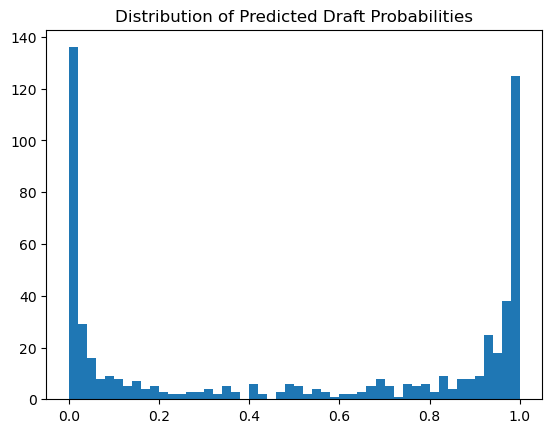

In [16]:
plt.hist(y_proba[:len(pcp_df)], bins=50)
plt.title('Distribution of Predicted Draft Probabilities')
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 67 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



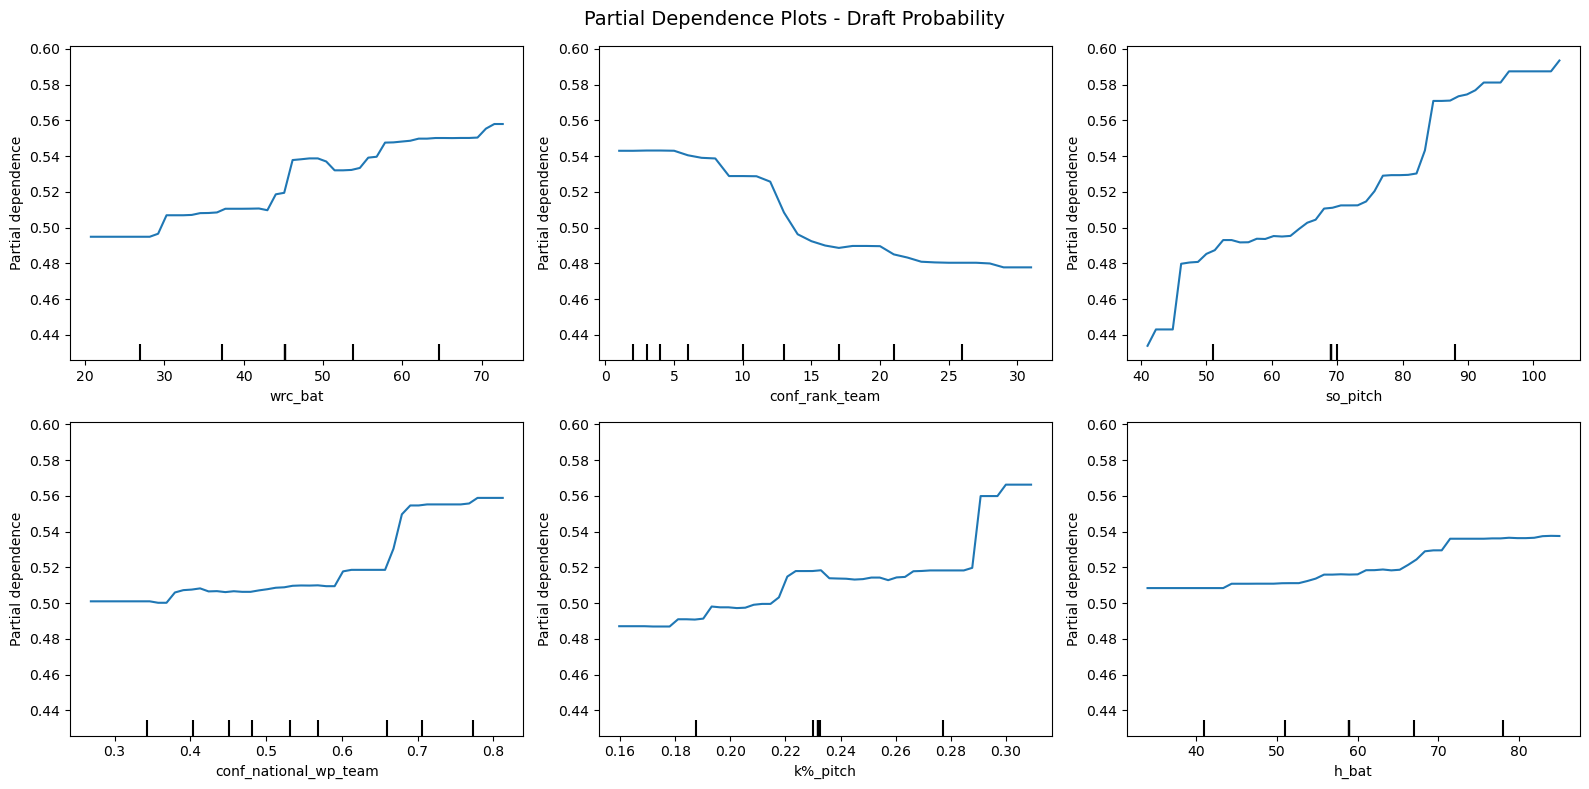

In [17]:
# Partial Dependence Plots - Draft Probability Classifier
top_n = 6
importances = draft_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:top_n].tolist()

# Fill NaN with median so sklearn can compute PDP grid (doesn't affect model)
X_pdp = X_balanced.fillna(X_balanced.median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    draft_model, X_pdp, features=top_indices,
    kind='average', ax=axes.flatten(),
    grid_resolution=50
)
fig.suptitle('Partial Dependence Plots - Draft Probability', fontsize=14)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 67 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



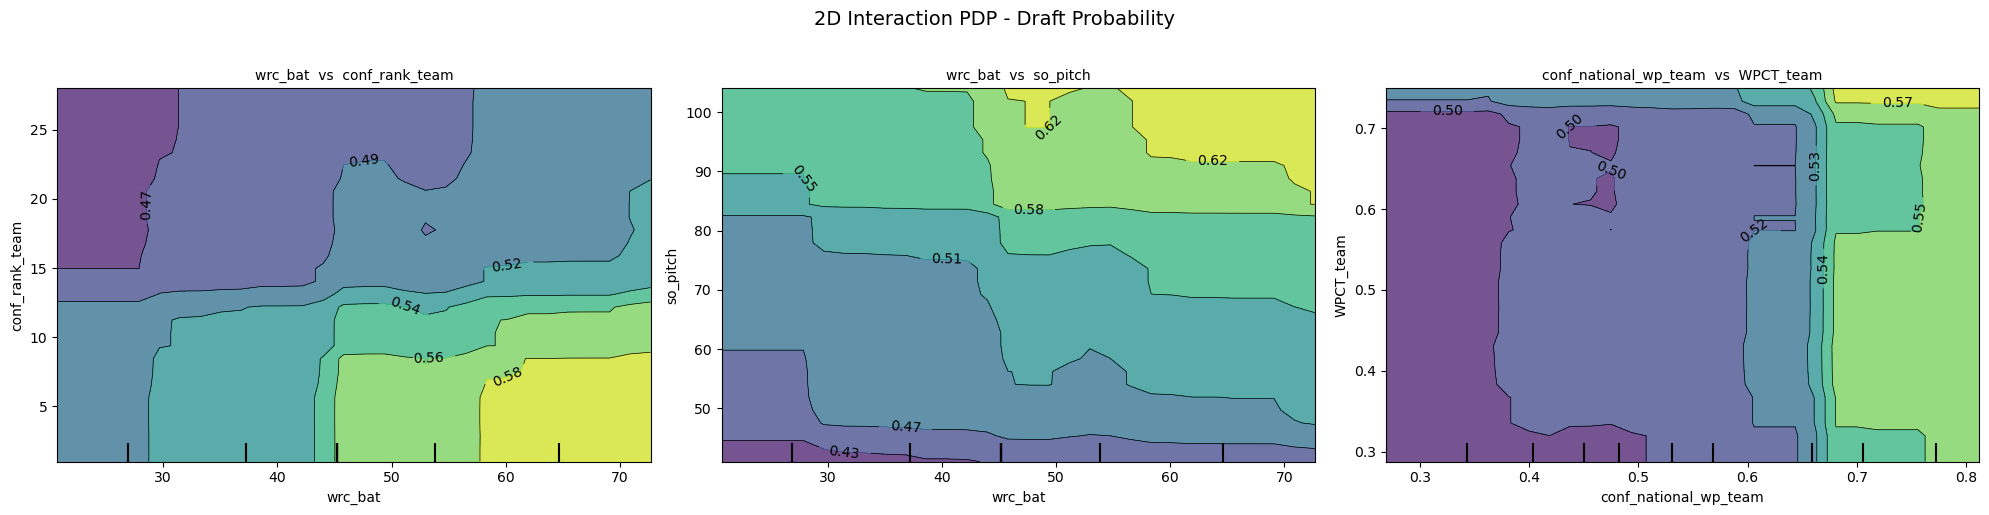

In [18]:
# 2D Interaction PDP - Draft Probability Classifier
# Shows how pairs of top features jointly affect draft probability
top_30 = np.argsort(draft_model.feature_importances_)[::-1][:30].tolist()
pairs = [(top_30[0], top_30[1]), (top_30[0], top_30[2]), (top_30[3], top_30[24])]
pair_labels = [(X_balanced.columns[a], X_balanced.columns[b]) for a, b in pairs]

X_pdp = X_balanced.fillna(X_balanced.median())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, pair, labels in zip(axes, pairs, pair_labels):
    disp = PartialDependenceDisplay.from_estimator(
        draft_model, X_pdp, features=[pair],
        kind='average', ax=ax, grid_resolution=30
    )
    ax.set_title(f'{labels[0]}  vs  {labels[1]}', fontsize=10)
fig.suptitle('2D Interaction PDP - Draft Probability', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Now to set up for pick prediction among drafted players

target_drafted = 'Drafted?'
target_pick = 'Pick'
year_col = 'year'

# Keep only drafted players
drafted_df = df[df[target_drafted] == 1].copy()
pd.options.display.max_columns = None
display(drafted_df.head(5))

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,PE_pct_team
2,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04,0.981752
22,22.0,Aaron Brown,2021,7.0,5.0,3.992218,14.0,14.0,3.0,0.0,0.0,85.2,348.0,67.0,38.0,38.0,13.0,15.0,7.0,4.0,0.0,113.0,11.871596,1.575876,7.533333,1.365759,0.324713,0.043103,0.281609,0.205521,0.957198,0.270000,0.720339,4.218935,-0.226717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.0,268.0,1,0.5129,6,0.5500,24.0,29.0,1.0,54.0,0.444,0.483,160.0,1634.0,397.0,0.243,42.0,0.78,86.0,1.59,442.2,247.0,206.0,4.19,1328.0,469.0,57.0,0.969,57.0,41.0,420.0,8.54,34.0,0.63,22.0,29.0,0.322,107.0,1.98,40.0,238.0,4.4,5.0,597.0,0.365,431.0,119.0,3.62,8.8,NaN,6.0,0.11,1.22,NaN,1.087838
32,20.0,Aaron Davenport,2021,3.0,6.0,3.738462,13.0,13.0,0.0,0.0,0.0,86.2,358.0,82.0,41.0,36.0,6.0,21.0,6.0,5.0,0.0,97.0,10.073077,2.180769,4.619048,0.623077,0.270950,0.058659,0.212290,0.247734,1.188462,0.333333,0.675944,3.634592,0.103869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,6.0,186.0,1,0.4919,14,0.4380,24.0,26.0,0.0,50.0,0.480,0.530,170.0,1669.0,469.0,0.281,37.0,0.74,84.0,1.68,431.0,250.0,201.0,4.20,1293.0,500.0,66.0,0.964,46.0,66.0,482.0,10.06,24.0,0.48,19.0,30.0,0.366,34.0,0.68,17.0,267.0,5.3,4.0,645.0,0.386,358.0,127.0,2.82,7.5,NaN,10.0,0.20,1.41,NaN,1.104167
47,21.0,Aaron McKeithan,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,180.0,221.0,50.0,35.0,12.0,0.0,3.0,35.0,24.0,26.0,20.0,12.0,3.0,0.0,10.0,2.0,1.0,0.277778,0.117647,0.090498,1.3,0.39819,0.394444,0.792634,0.116667,3.689838,0.29375,-0.168267,37.26055,1.809693,0.377073,105.104793,1.0,16.0,481.0,1,0.5129,6,0.5500,40.0,21.0,0.0,61.0,0.656,0.594,218.0,1997.0,594.0,0.297,39.0,0.64,130.0,2.13,504.2,339.0,301.0,5.37,1514.0,484.0,58.0,0.972,81.0,47.0,480.0,8.56,66.0,1.08,26.0,11.0,0.375,68.0,1.11,17.0,417.0,6.8,3.0,940.0,0.471,557.0,280.0,1.99,9.9,NaN,9.0,0.15,1.51,NaN,0.905488
59,20.0,Aaron Savary,2025,7.0,2.0,4.369294,15.0,15.0,0.0,0.0,0.0,80.1,342.0,67.0,39.0,39.0,10.0,33.0,15.0,1.0,2.0,82.0,9.186722,3.697095,2.484848,1.120332,0.239766,0.096491,0.143275,0.227891,1.244813,0.282

In [20]:
import json
import os
from difflib import SequenceMatcher

def load_draft_jsons(json_dir: str) -> pd.DataFrame:
    """Load all mlb_draft_YYYY.json files and flatten into a DataFrame."""
    rows = []
    for fname in sorted(os.listdir(json_dir)):
        if not fname.endswith(".json"):
            continue
        print(f"  Loading {fname}...")
        with open(os.path.join(json_dir, fname), "r", encoding="utf-8") as f:
            data = json.load(f)

        draft_year = data.get("drafts", {}).get("draftYear")
        if draft_year is None:
            print(f"    ⚠️ No draftYear found, skipping")
            continue

        for rd in data.get("drafts", {}).get("rounds", []):
            for pick in rd.get("picks", []):
                person = pick.get("person", {}) or {}
                pos = person.get("primaryPosition", {}) or {}
                bat = person.get("batSide", {}) or {}
                pitch = person.get("pitchHand", {}) or {}

                ov = pick.get("pickOverall") or pick.get("displayPickNumber")

                rows.append({
                    "year": int(draft_year),
                    "Pick": float(ov) if ov else None,
                    "api_name": person.get("fullName"),
                    "api_batSide": bat.get("code"),
                    "api_pitchHand": pitch.get("code"),
                    "api_primaryPos": pos.get("abbreviation"),
                    "api_weight": person.get("weight"),
                    "api_height": person.get("height"),
                    "api_pickValue": float(pick["pickValue"]) / 1e6 if pick.get("pickValue") else None,
                    "api_signingBonus": float(pick["signingBonus"]) / 1e6 if pick.get("signingBonus") else None,
                })

    df = pd.DataFrame(rows)
    if df.empty:
        print("⚠️ No picks loaded! Check your JSON_DIR path and file contents.")
        return df
    return df.drop_duplicates(subset=["year", "Pick"])


def name_similarity(a, b) -> float:
    if pd.isna(a) or pd.isna(b):
        return 0.0
    return round(SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio() * 100, 1)


def height_to_inches(h):
    if pd.isna(h):
        return None
    try:
        parts = str(h).replace('"', '').split("'")
        return int(parts[0].strip()) * 12 + int(parts[1].strip())
    except (ValueError, IndexError):
        return None


# ── Load JSONs ────────────────────────────────────────────────────────
JSON_DIR = "./MLBStatsAPIDraftDataAccess"

print(f"Looking in: {os.path.abspath(JSON_DIR)}")
print(f"Files found: {os.listdir(JSON_DIR)}\n")

api_df = load_draft_jsons(JSON_DIR)

print(f"\nAPI data: {len(api_df)} picks across years {sorted(api_df['year'].unique()) if not api_df.empty else 'NONE'}")
print(f"Drafted data: {len(drafted_df)} rows, Pick dtype={drafted_df['Pick'].dtype}, year dtype={drafted_df['year'].dtype}")

# ── Print unique string values before mapping ─────────────────────────
print(f"\nUnique api_batSide values:   {sorted(api_df['api_batSide'].dropna().unique())}")
print(f"Unique api_pitchHand values: {sorted(api_df['api_pitchHand'].dropna().unique())}")
print(f"Unique api_primaryPos values: {sorted(api_df['api_primaryPos'].dropna().unique())}")
print(f"Unique api_height values:    {sorted(api_df['api_height'].dropna().unique())}")

# ── Ensure matching dtypes ────────────────────────────────────────────
drafted_df["Pick"] = drafted_df["Pick"].astype(float)
drafted_df["year"] = drafted_df["year"].astype(int)

if not api_df.empty:
    api_df["Pick"] = api_df["Pick"].astype(float)
    api_df["year"] = api_df["year"].astype(int)

    # Spot check: do the keys overlap?
    draft_keys = set(zip(drafted_df["year"], drafted_df["Pick"]))
    api_keys = set(zip(api_df["year"], api_df["Pick"]))
    overlap = draft_keys & api_keys
    print(f"\nKey overlap: {len(overlap)} matches out of {len(draft_keys)} drafted rows")

    # Merge
    drafted_df = drafted_df.merge(api_df, on=["year", "Pick"], how="left")

    # Name match
    drafted_df["name_match_pct"] = drafted_df.apply(
        lambda r: name_similarity(r["nameascii"], r["api_name"]), axis=1
    )

    print(f"\nMatched: {drafted_df['api_name'].notna().sum()} / {len(drafted_df)}")

    # Drop bad matches
    MATCH_THRESHOLD = 70
    low_match = drafted_df[drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)]
    if len(low_match) > 0:
        print(f"\n⚠️ Dropping {len(low_match)} rows with name match < {MATCH_THRESHOLD}%:")
        print(low_match[["year", "Pick", "nameascii", "api_name", "name_match_pct"]].to_string(index=False))

    drafted_df = drafted_df[~drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)].copy()
    print(f"\nRows remaining: {len(drafted_df)}")

    # ── Encode string columns to numeric ──────────────────────────────
    bat_map = {"R": 0, "L": 1, "S": 2}
    drafted_df["api_batSide"] = drafted_df["api_batSide"].map(bat_map)

    pitch_map = {"R": 0, "L": 1, "S": 2}
    drafted_df["api_pitchHand"] = drafted_df["api_pitchHand"].map(pitch_map)

    pos_map = {
        "C": 1, "SS": 2, "2B": 3, "3B": 4, "CF": 5,
        "LF": 6, "RF": 7, "IF": 8, "1B": 9, "OF": 10, "DH": 11,
        "P": 12, "TWP": 13,
    }
    drafted_df["api_primaryPos"] = drafted_df["api_primaryPos"].map(pos_map)

    drafted_df["api_height"] = drafted_df["api_height"].apply(height_to_inches).astype(float)

    # Verify
    print("\nConverted dtypes:")
    for col in ["api_batSide", "api_pitchHand", "api_primaryPos", "api_height", "api_weight"]:
        print(f"  {col}: {drafted_df[col].dtype}, unique: {sorted(drafted_df[col].dropna().unique())}")

else:
    print("\n❌ No API data loaded — nothing to merge.")

Looking in: /Users/mateobiggs/ncaaBaseballDraft-Predictor/CSV+Code Files/trial_xgBoost/MLBStatsAPIDraftDataAccess
Files found: ['enrich_draft_dataV2.py', 'statsapi_draft_2021.json', 'statsapi_teams.json', 'enrich_draft_data.py', 'statsapi_draft_2023.json', 'statsapi_draft_2022.json', 'statsapi_draft_2025.json', 'statsapi_draft_2024.json']

  Loading statsapi_draft_2021.json...
  Loading statsapi_draft_2022.json...
  Loading statsapi_draft_2023.json...
  Loading statsapi_draft_2024.json...
  Loading statsapi_draft_2025.json...
  Loading statsapi_teams.json...
    ⚠️ No draftYear found, skipping

API data: 3072 picks across years [2021, 2022, 2023, 2024, 2025]
Drafted data: 1438 rows, Pick dtype=float64, year dtype=int64

Unique api_batSide values:   ['L', 'R', 'S']
Unique api_pitchHand values: ['L', 'R', 'S']
Unique api_primaryPos values: ['1B', '2B', '3B', 'C', 'CF', 'IF', 'LF', 'OF', 'P', 'RF', 'SS', 'TWP']
Unique api_height values:    ['5\' 10"', '5\' 11"', '5\' 4"', '5\' 5"', '5\' 6

In [21]:
draftedClean_df = drafted_df.drop(columns=['api_name', 'name_match_pct'])

print(draftedClean_df.columns.tolist())
display(draftedClean_df.head(10))

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,PE_pct_team,api_batSide,api_pitchHand,api_primaryPos,api_weight,api_height,api_pickValue,api_signingBonus
0,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04,0.981752,0,0,12,210,75.0,0.5050,0.4775
1,22.0,Aaron Brown,2021,7.0,5.0,3.992218,14.0,14.0,3.0,0.0,0.0,85.2,348.0,67.0,38.0,38.0,13.0,15.0,7.0,4.0,0.0,113.0,11.871596,1.575876,7.533333,1.365759,0.324713,0.043103,0.281609,0.205521,0.957198,0.270000,0.720339,4.218935,-0.226717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.0,268.0,1,0.5129,6,0.5500,24.0,29.0,1.0,54.0,0.444,0.483,160.0,1634.0,397.0,0.243,42.0,0.78,86.0,1.59,442.2,247.0,206.0,4.19,1328.0,469.0,57.0,0.969,57.0,41.0,420.0,8.54,34.0,0.63,22.0,29.0,0.322,107.0,1.98,40.0,238.0,4.4,5.0,597.0,0.365,431.0,119.0,3.62,8.8,NaN,6.0,0.11,1.22,NaN,1.087838,0,0,12,220,76.0,0.1546,0.0575
2,20.0,Aaron Davenport,2021,3.0,6.0,3.738462,13.0,13.0,0.0,0.0,0.0,86.2,358.0,82.0,41.0,36.0,6.0,21.0,6.0,5.0,0.0,97.0,10.073077,2.180769,4.619048,0.623077,0.270950,0.058659,0.212290,0.247734,1.188462,0.333333,0.675944,3.634592,0.103869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,6.0,186.0,1,0.4919,14,0.4380,24.0,26.0,0.0,50.0,0.480,0.530,170.0,1669.0,469.0,0.281,37.0,0.74,84.0,1.68,431.0,250.0,201.0,4.20,1293.0,500.0,66.0,0.964,46.0,66.0,482.0,10.06,24.0,0.48,19.0,30.0,0.366,34.0,0.68,17.0,267.0,5.3,4.0,645.0,0.386,358.0,127.0,2.82,7.5,NaN,10.0,0.20,1.41,NaN,1.104167,0,0,12,185,72.0,0.2594,0.4500
3,21.0,Aaron McKeithan,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,180.0,221.0,50.0,35.0,12.0,0.0,3.0,35.0,24.0,26.0,20.0,12.0,3.0,0.0,10.0,2.0,1.0,0.277778,0.117647,0.090498,1.300000,0.398190,0.394444,0.792634,0.116667,3.689838,0.293750,-0.168267,37.260550,1.809693,0.377073,105.104793,1.0,16.0,481.0,1,0.5129,6,0.5500,40.0,21.0,0.0,61.0,0.656,0.594,218.0,1997.0,594.0,0.297,39.0,0.64,130.0,2.13,504.2,339.0,301.0,5.37,1514.0,484.0,58.0,0.972,81.0,47.0,480.0,8.56,66.0,1.08,26.0,11.0,0.375,68.0,1.11,17.0,417.0,6.8,3.0,940.0,0.471,557.0,280.0,1.99,9.9,NaN,9.0,0.15,1.51,NaN,0.905488,0,0,1,225,71.0,N

In [22]:
# Create college-only rank as target for each year
# Filter to college players only and rank within each year
draftedClean_df = drafted_df[drafted_df[target_drafted] == 1].copy()

# Create college-only draft order within each year
draftedClean_df = draftedClean_df.sort_values([year_col, target_pick])
draftedClean_df['College_Draft_Order'] = draftedClean_df.groupby(year_col).cumcount() + 1

# Normalize to 0-1 so rankings are comparable across years with different class sizes
draftedClean_df['College_Draft_Pct'] = draftedClean_df.groupby(year_col)['College_Draft_Order'].transform(
    lambda x: (x - 1) / (len(x) - 1) if len(x) > 1 else 0.5
)

print("College draft order examples:")
print(draftedClean_df[[year_col, 'nameascii', target_pick, 'College_Draft_Order', 'College_Draft_Pct']].head(15))
print(f"\nPlayers per year:")
print(draftedClean_df.groupby(year_col).size())

College draft order examples:
      year         nameascii  Pick  College_Draft_Order  College_Draft_Pct
592   2021       Henry Davis   1.0                    1           0.000000
644   2021       Jack Leiter   2.0                    2           0.003484
379   2021     Colton Cowser   5.0                    3           0.006969
1229  2021       Sam Bachman   9.0                    4           0.010453
902   2021      Kumar Rocker  10.0                    5           0.013937
1384  2021       Will Bednar  14.0                    6           0.017422
1226  2021       Sal Frelick  15.0                    7           0.020906
1035  2021  Michael McGreevy  18.0                    8           0.024390
579   2021    Gunnar Hoglund  19.0                    9           0.027875
1338  2021      Trey Sweeney  20.0                   10           0.031359
562   2021    Gavin Williams  23.0                   11           0.034843
1197  2021       Ryan Cusick  24.0                   12           0.03

In [23]:
# XGBoost regression to predict college draft order, using just College_Draft_Order as target (not pick number)

test_year = draftedClean_df[year_col].max()

train_df = draftedClean_df[draftedClean_df[year_col] < test_year]
test_df  = draftedClean_df[draftedClean_df[year_col] == test_year]

api_features = ['api_batSide', 'api_pitchHand', 'api_primaryPos', 'api_weight', 'api_height']
all_features = features + api_features

pick_features = [f for f in all_features if f not in redundant_features]

print(train_df.columns.tolist())
X_train = train_df[pick_features]
y_train = train_df['College_Draft_Order']

X_test = test_df[pick_features]
y_test_order = test_df['College_Draft_Order']

model_rank = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae'
)

model_rank.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test_order)],
    verbose=50
)

preds = model_rank.predict(X_test)
pred_order = pd.Series(preds).rank(method='min').astype(int).values
actual_order = y_test_order.values

print(f"College draft class sizes per year:")
print(draftedClean_df.groupby(year_col).size())

corr_order, p_value = spearmanr(actual_order, pred_order)
mae_order = mean_absolute_error(actual_order, pred_order)

print(f"\nCollege-Only Rank Model — Raw Order Target (n={len(y_test_order)}):")
print(f"  Spearman: {corr_order:.3f} (p={p_value:.2e})")
print(f"  MAE:      {mae_order:.1f}")

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

In [24]:
corr_order, p_value = spearmanr(actual_order, pred_order)

# Fisher z-transform for confidence interval
n = len(actual_order)
z = np.arctanh(corr_order)
se = 1 / np.sqrt(n - 3)
alpha = 0.05
z_crit = 1.96  # for 95% CI

ci_low = np.tanh(z - z_crit * se)
ci_high = np.tanh(z + z_crit * se)

print(f"Spearman: {corr_order:.3f} (p={p_value:.2e})")
print(f"95% CI:   [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Range:    [{ci_high - ci_low:.3f}]")

Spearman: 0.608 (p=4.80e-29)
95% CI:   [0.527, 0.677]
Range:    [0.150]


In [25]:
# Show top features by importance from the trained classifier
importance = model_rank.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(120))


All Features by Importance:
                   Feature    Importance
61                 wrc_bat  95042.671875
107                SO_team  92941.226562
18                so_pitch  89379.843750
66          conf_rank_team  57033.152344
53                bb/k_bat  54515.433594
25             k-bb%_pitch  53732.605469
23                k%_pitch  53662.070312
65           conf_rpi_team  53522.484375
67   conf_national_wp_team  51440.441406
27              whip_pitch  49701.285156
9                tbf_pitch  39549.140625
56                 ops_bat  38785.003906
4                 gs_pitch  37676.722656
62                wraa_bat  35884.386719
30               fip_pitch  34398.886719
39                  hr_bat  31639.312500
3                  g_pitch  28169.232422
93               HAPG_team  28033.347656
42                  bb_bat  27344.767578
7                 sv_pitch  26904.521484
35                   h_bat  25463.210938
63                woba_bat  25046.152344
57                 iso_bat  

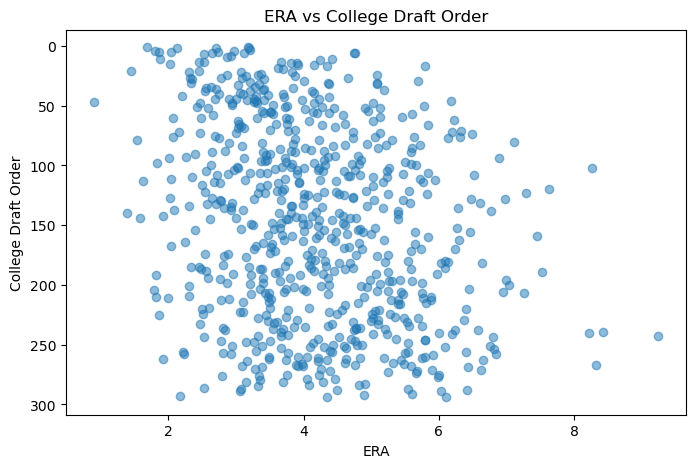

In [26]:
plot_df = draftedClean_df[['era_pitch', 'College_Draft_Order']].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df['era_pitch'], plot_df['College_Draft_Order'], alpha=0.5)
plt.xlabel('ERA')
plt.ylabel('College Draft Order')
plt.gca().invert_yaxis()  # pick 1 at top
plt.title('ERA vs College Draft Order')
plt.show()

In [27]:
# Pick the features on the PCP axes
pcp_features = ['era_pitch', 'fip_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

# Build a temporary df with those features + the target
pcp_df = draftedClean_df[pcp_features + ['College_Draft_Order']].dropna()

fig = px.parallel_coordinates(
    pcp_df,
    color='College_Draft_Order',
    dimensions=pcp_features,
    color_continuous_scale=['#EF553B', '#636EFA'],  # red = 0, blue = 1
    title='Parallel Coordinates: Pitching Features by College Draft Order'
)

fig.update_layout(width=1000, height=500)
fig.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 67 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



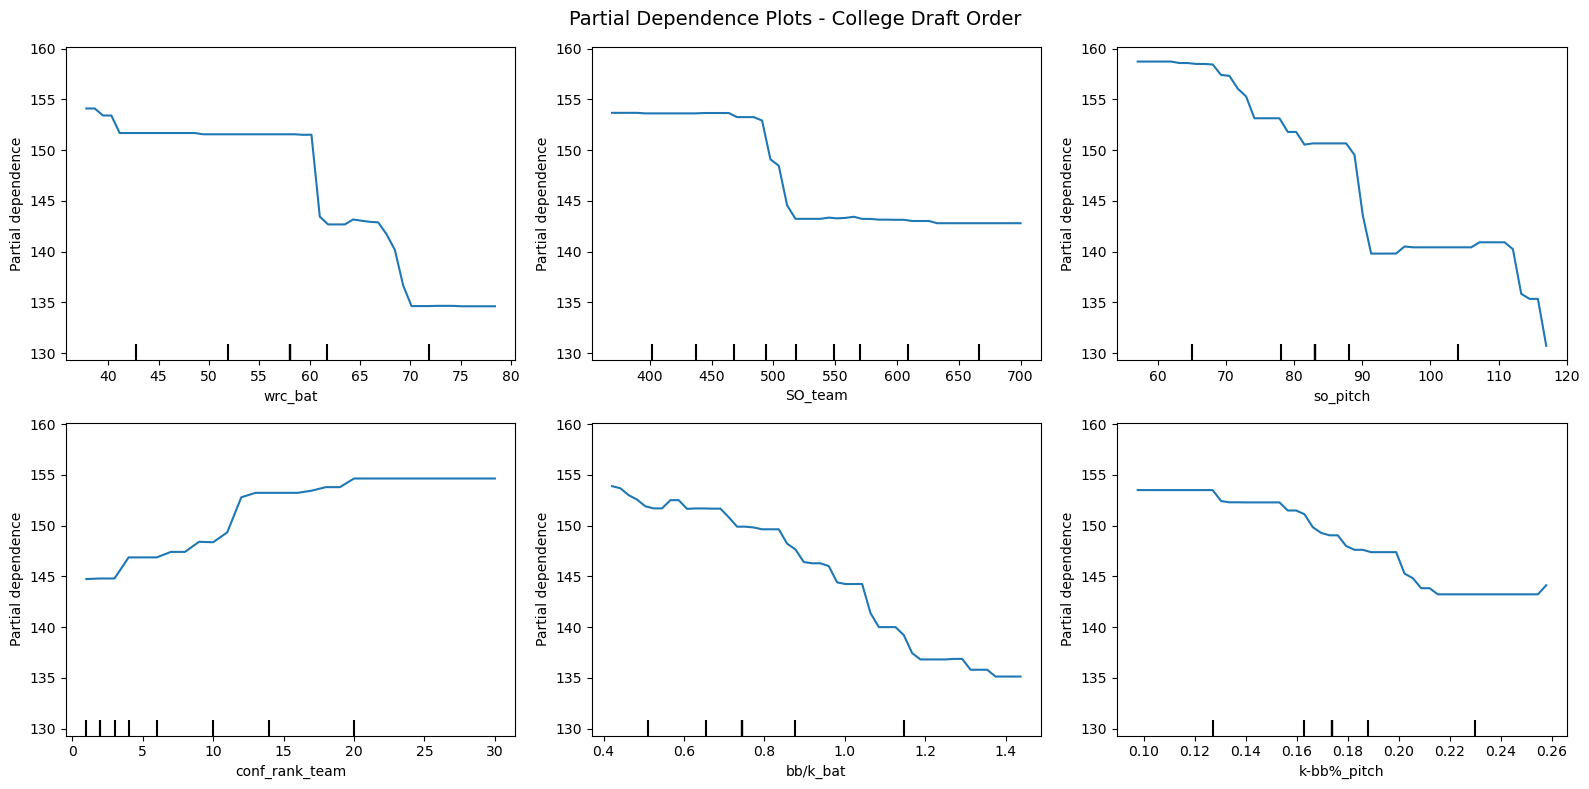

In [28]:
# Partial Dependence Plots - College Draft Order Model
top_n = 6
importances_rank = model_rank.feature_importances_
top_indices_rank = np.argsort(importances_rank)[::-1][:top_n].tolist()

X_pdp_rank = train_df[pick_features].fillna(train_df[pick_features].median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    model_rank, X_pdp_rank, features=top_indices_rank,
    kind='average', ax=axes.flatten(),
    grid_resolution=50
)
fig.suptitle('Partial Dependence Plots - College Draft Order', fontsize=14)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 67 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



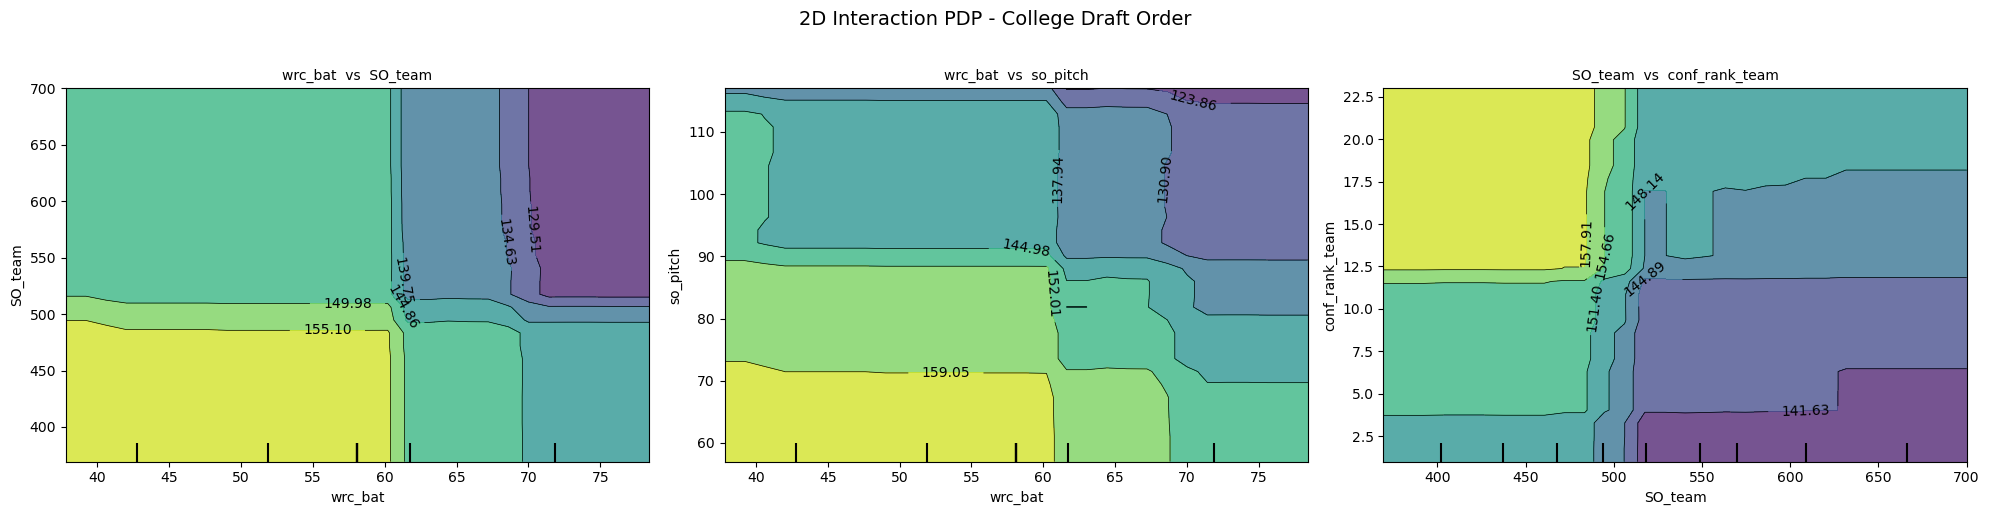

In [29]:
# 2D Interaction PDP - College Draft Order Model
top_4_rank = np.argsort(model_rank.feature_importances_)[::-1][:4].tolist()
pairs_rank = [(top_4_rank[0], top_4_rank[1]), (top_4_rank[0], top_4_rank[2]), (top_4_rank[1], top_4_rank[3])]
pair_labels_rank = [(train_df[pick_features].columns[a], train_df[pick_features].columns[b]) for a, b in pairs_rank]

X_pdp_rank = train_df[pick_features].fillna(train_df[pick_features].median())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, pair, labels in zip(axes, pairs_rank, pair_labels_rank):
    disp = PartialDependenceDisplay.from_estimator(
        model_rank, X_pdp_rank, features=[pair],
        kind='average', ax=ax, grid_resolution=30
    )
    ax.set_title(f'{labels[0]}  vs  {labels[1]}', fontsize=10)
fig.suptitle('2D Interaction PDP - College Draft Order', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [30]:
# Build results dataframe
results_rank_df = pd.DataFrame({
    'name': test_df['nameascii'].values,
    'Predicted_College_Order': pred_order,
    'Actual_College_Order': actual_order,
})

results_rank_df = results_rank_df.sort_values('Actual_College_Order').reset_index(drop=True)

print(f"Player College Draft Order Predictions (Test Year: {test_year})")
print(f"Total college draftees: {len(results_rank_df)}\n")
display(results_rank_df.head(20))

Player College Draft Order Predictions (Test Year: 2025)
Total college draftees: 274



,name,Predicted_College_Order,Actual_College_Order
0,Kade Anderson,2,1
1,Liam Doyle,1,2
2,Aiva Arquette,12,3
3,Jamie Arnold,9,4
4,Gavin Kilen,21,5
5,Kyson Witherspoon,8,6
6,Marek Houston,32,7
7,Ike Irish,6,8
8,Andrew Fischer,3,9
9,Jace LaViolette,53,10


---
## Percent-Based College Draft Order Model

In [31]:
# XGBoost regression to predict College_Draft_Pct (normalized 0-1)
y_train_pct = train_df['College_Draft_Pct']
y_test_pct = test_df['College_Draft_Pct']

model_rank_pct = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
    random_state=42, early_stopping_rounds=50, eval_metric='mae'
)
model_rank_pct.fit(X_train, y_train_pct,
                   eval_set=[(X_test, y_test_pct)], verbose=50)

preds_pct = model_rank_pct.predict(X_test)
pred_order_pct = pd.Series(preds_pct).rank(method='min').astype(int).values

corr_pct, p_pct = spearmanr(actual_order, pred_order_pct)
mae_pct = mean_absolute_error(y_test_pct.values, preds_pct)

print(f"\nCollege-Only Rank Model - Percent Target (n={len(y_test_pct)}):")
print(f"  Spearman (rank): {corr_pct:.3f} (p={p_pct:.2e})")
print(f"  MAE (pct):       {mae_pct:.4f}")
print(f"\nComparison:")
print(f"  Raw Order Model Spearman: {corr_order:.3f}")
print(f"  Pct Model Spearman:       {corr_pct:.3f}")

[0]	validation_0-mae:0.24954
[50]	validation_0-mae:0.21215
[100]	validation_0-mae:0.20049
[150]	validation_0-mae:0.19630
[200]	validation_0-mae:0.19483
[250]	validation_0-mae:0.19395
[300]	validation_0-mae:0.19355
[334]	validation_0-mae:0.19386

College-Only Rank Model - Percent Target (n=274):
  Spearman (rank): 0.590 (p=4.75e-27)
  MAE (pct):       0.1932

Comparison:
  Raw Order Model Spearman: 0.608
  Pct Model Spearman:       0.590


In [32]:
corr_order_pct, p_value_pct = spearmanr(actual_order, pred_order_pct)

# Fisher z-transform for confidence interval
n = len(actual_order)
z = np.arctanh(corr_order_pct)
se = 1 / np.sqrt(n - 3)
alpha = 0.05
z_crit = 1.96  # for 95% CI

ci_low = np.tanh(z - z_crit * se)
ci_high = np.tanh(z + z_crit * se)

print(f"Spearman: {corr_order_pct:.3f} (p={p_value_pct:.2e})")
print(f"95% CI:   [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Range:    [{ci_high - ci_low:.3f}]")

Spearman: 0.590 (p=4.75e-27)
95% CI:   [0.507, 0.662]
Range:    [0.155]


In [33]:
# Percent model results table
results_pct_df = pd.DataFrame({
    'name': test_df['nameascii'].values,
    'Predicted_Pct': preds_pct,
    'Actual_Pct': y_test_pct.values,
    'Predicted_Order_from_Pct': pred_order_pct,
    'Actual_College_Order': actual_order,
})
results_pct_df = results_pct_df.sort_values('Actual_College_Order').reset_index(drop=True)
display(results_pct_df.head(20))

,name,Predicted_Pct,Actual_Pct,Predicted_Order_from_Pct,Actual_College_Order
0,Kade Anderson,0.072057,0.000000,2,1
1,Liam Doyle,0.060768,0.003663,1,2
2,Aiva Arquette,0.126709,0.007326,10,3
3,Jamie Arnold,0.093309,0.010989,4,4
4,Gavin Kilen,0.228528,0.014652,25,5
5,Kyson Witherspoon,0.111233,0.018315,7,6
6,Marek Houston,0.199841,0.021978,16,7
7,Ike Irish,0.113128,0.025641,8,8
8,Andrew Fischer,0.079062,0.029304,3,9
9,Jace LaViolette,0.410838,0.032967,73,10


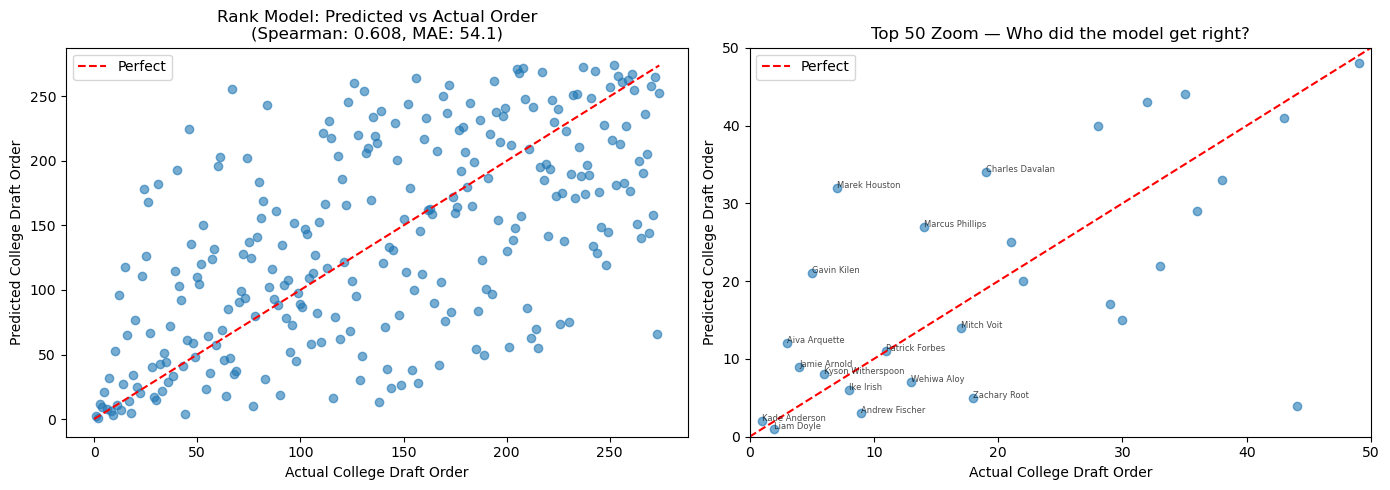

In [34]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_test = len(actual_order)

axes[0].scatter(actual_order, pred_order, alpha=0.6)
axes[0].plot([0, n_test], [0, n_test], 'r--', label='Perfect')
axes[0].set_xlabel('Actual College Draft Order')
axes[0].set_ylabel('Predicted College Draft Order')
axes[0].set_title(f'Rank Model: Predicted vs Actual Order\n(Spearman: {corr_order:.3f}, MAE: {mae_order:.1f})')
axes[0].legend()

axes[1].scatter(actual_order, pred_order, alpha=0.6)
# Add player labels for top 20
for _, row in results_rank_df.head(20).iterrows():
    if row['Actual_College_Order'] <= 20 or row['Predicted_College_Order'] <= 20:
        axes[1].annotate(row['name'], (row['Actual_College_Order'], row['Predicted_College_Order']),
                         fontsize=6, alpha=0.7)
axes[1].plot([0, 50], [0, 50], 'r--', label='Perfect')
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)
axes[1].set_xlabel('Actual College Draft Order')
axes[1].set_ylabel('Predicted College Draft Order')
axes[1].set_title('Top 50 Zoom — Who did the model get right?')
axes[1].legend()

plt.tight_layout()
plt.show()

In [35]:
prospects = pd.read_csv('mlb_draft_prospects/mlb_2025_draft_prospects_top250.csv')

# Compare with MLB Pipeline on matched players
results_rank_df['name_clean'] = results_rank_df['name'].str.strip().str.lower()
prospects['name_clean'] = prospects['name'].str.strip().str.lower()

comp = results_rank_df.merge(prospects[['name_clean', 'rank']], on='name_clean', how='inner')

# Re-rank everything among only matched players
comp = comp.sort_values('Actual_College_Order').reset_index(drop=True)
comp['Actual_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('Predicted_College_Order').reset_index(drop=True)
comp['Pred_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('rank').reset_index(drop=True)
comp['Pipeline_Order_Matched'] = range(1, len(comp) + 1)

corr_you, p_you = spearmanr(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
corr_pipe, p_pipe = spearmanr(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])
mae_you = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
mae_pipe = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])

print(f"Head-to-Head on Matched College Players (n={len(comp)})")
print(f"{'Comparison':<45} {'Spearman':>10}    {'P-Value':>8}  {'MAE':>10}")
print("-" * 80)
print(f"{'Your Rank Model vs Actual':<45} {corr_you:>10.3f}    {p_you:.2e} {mae_you:>10.1f}")
print(f"{'MLB Pipeline vs Actual':<45} {corr_pipe:>10.3f}    {p_pipe:.2e} {mae_pipe:>10.1f}")

comp = comp[['name', 'Pipeline_Order_Matched', 'Predicted_College_Order', 'Actual_College_Order']].copy()
comp.columns = ['name', 'MLB_Pipeline_College_Order', 'Predicted_College_Order', 'Actual_College_Order']
display(comp.sort_values('Actual_College_Order').reset_index(drop=True).head(25))

Head-to-Head on Matched College Players (n=97)
Comparison                                      Spearman     P-Value         MAE
--------------------------------------------------------------------------------
Your Rank Model vs Actual                          0.548    6.04e-09       20.4
MLB Pipeline vs Actual                             0.838    1.06e-26       11.3


,name,MLB_Pipeline_College_Order,Predicted_College_Order,Actual_College_Order
0,Kade Anderson,1,2,1
1,Liam Doyle,4,1,2
2,Aiva Arquette,3,12,3
3,Jamie Arnold,2,9,4
4,Gavin Kilen,11,21,5
5,Kyson Witherspoon,5,8,6
6,Marek Houston,7,32,7
7,Ike Irish,6,6,8
8,Andrew Fischer,12,3,9
9,Jace LaViolette,10,53,10


## V6 — Multi-Year MLB Pipeline Benchmark (2021–2025)

The cells below extend the cell-35 single-year comparison to all five years of MLB Pipeline top-250 prospect rankings. They:

1. Load `mlb_<year>_draft_prospects_top250.csv` for 2021–2025 from `mlb_draft_prospects/`.
2. Generate out-of-fold per-year predictions from the rank model (each year predicted by a model that did NOT see it during training).
3. Run a per-year head-to-head: **Your Model** vs **MLB Pipeline** vs **Actual draft order**.
4. Run a developmental-success benchmark on 2021–2023 cohorts using `current_level` (post-draft ground truth).

`current_level` is used **only** for the eval in cell *develop-eval*. It is never merged into the training features.

In [36]:
# Load all 5 years of MLB Pipeline top-250 prospect CSVs.
PROSPECTS_DIR = 'mlb_draft_prospects'
PROSPECT_YEARS = [2021, 2022, 2023, 2024, 2025]

prospects_by_year = {}
for y in PROSPECT_YEARS:
    p = pd.read_csv(f'{PROSPECTS_DIR}/mlb_{y}_draft_prospects_top250.csv')
    p['name_clean'] = p['name'].astype(str).str.strip().str.lower()
    p['year'] = y
    prospects_by_year[y] = p

all_prospects = pd.concat(prospects_by_year.values(), ignore_index=True)
print(f"Loaded prospects for years: {sorted(prospects_by_year.keys())}")
print(f"Total prospect rows: {len(all_prospects)}")
print(f"\ncurrent_level distribution (all years pooled):")
print(all_prospects['current_level'].fillna('BLANK').value_counts().to_string())

Loaded prospects for years: [2021, 2022, 2023, 2024, 2025]
Total prospect rows: 1250

current_level distribution (all years pooled):
current_level
A+       265
AA       221
BLANK    213
A        181
AAA      174
MLB      115
ROK       81


In [37]:
# Out-of-fold per-year rank-model predictions for 2021-2025.
# For each year y, train on (years != y) and predict on year y.
# Result: every year has predictions from a model that did NOT see that year during training.
years_all = sorted(draftedClean_df[year_col].unique())
print(f"Running leave-one-year-out CV across: {years_all}")

oof_frames = []
for y in years_all:
    train_slice = draftedClean_df[draftedClean_df[year_col] != y]
    test_slice  = draftedClean_df[draftedClean_df[year_col] == y]

    if len(test_slice) == 0:
        continue

    X_tr = train_slice[pick_features]
    y_tr = train_slice['College_Draft_Order']
    X_te = test_slice[pick_features]
    y_te = test_slice['College_Draft_Order']

    m = xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
        colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
        random_state=42, early_stopping_rounds=50, eval_metric='mae'
    )
    m.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    preds = m.predict(X_te)
    pred_order = pd.Series(preds).rank(method='min').astype(int).values

    oof_frames.append(pd.DataFrame({
        'name': test_slice['nameascii'].values,
        'year': y,
        'Predicted_College_Order': pred_order,
        'Actual_College_Order': y_te.values,
    }))

oof_results_rank_df = pd.concat(oof_frames, ignore_index=True)
oof_results_rank_df['name_clean'] = oof_results_rank_df['name'].astype(str).str.strip().str.lower()

print(f"\nOOF predictions: {len(oof_results_rank_df)} players across {oof_results_rank_df['year'].nunique()} years")
print(oof_results_rank_df.groupby('year').size().to_string())

Running leave-one-year-out CV across: [2021, 2022, 2023, 2024, 2025]

OOF predictions: 1433 players across 5 years
year
2021    288
2022    296
2023    301
2024    274
2025    274


In [38]:
# Per-year head-to-head: Your Model vs MLB Pipeline vs Actual draft order.
# Restricted to matched players (in both the year's draftees and the top-250 list).
per_year_rows = []
all_matched = []

for y in PROSPECT_YEARS:
    yr_oof = oof_results_rank_df[oof_results_rank_df['year'] == y]
    yr_prosp = prospects_by_year[y]
    merged = yr_oof.merge(yr_prosp[['name_clean', 'rank']], on='name_clean', how='inner')

    if len(merged) < 5:
        per_year_rows.append({'year': y, 'n_matched': len(merged),
                              'spearman_model': np.nan, 'spearman_pipeline': np.nan,
                              'mae_model': np.nan, 'mae_pipeline': np.nan})
        continue

    merged = merged.sort_values('Actual_College_Order').reset_index(drop=True)
    merged['actual_order_m'] = range(1, len(merged) + 1)
    merged = merged.sort_values('Predicted_College_Order').reset_index(drop=True)
    merged['pred_order_m'] = range(1, len(merged) + 1)
    merged = merged.sort_values('rank').reset_index(drop=True)
    merged['pipeline_order_m'] = range(1, len(merged) + 1)

    sp_m, _ = spearmanr(merged['actual_order_m'], merged['pred_order_m'])
    sp_p, _ = spearmanr(merged['actual_order_m'], merged['pipeline_order_m'])
    mae_m = mean_absolute_error(merged['actual_order_m'], merged['pred_order_m'])
    mae_p = mean_absolute_error(merged['actual_order_m'], merged['pipeline_order_m'])

    per_year_rows.append({'year': y, 'n_matched': len(merged),
                          'spearman_model': sp_m, 'spearman_pipeline': sp_p,
                          'mae_model': mae_m, 'mae_pipeline': mae_p})
    merged['year'] = y
    all_matched.append(merged)

per_year_h2h_df = pd.DataFrame(per_year_rows)
matched_pool = pd.concat(all_matched, ignore_index=True) if all_matched else pd.DataFrame()

print("=== Per-year head-to-head: stats-only XGBoost vs MLB Pipeline (vs actual draft order) ===\n")
display(per_year_h2h_df.round(3))

if len(matched_pool) > 0:
    n_total = len(matched_pool)
    sp_m_avg = per_year_h2h_df['spearman_model'].mean()
    sp_p_avg = per_year_h2h_df['spearman_pipeline'].mean()
    mae_m_avg = per_year_h2h_df['mae_model'].mean()
    mae_p_avg = per_year_h2h_df['mae_pipeline'].mean()
    print(f"\nMean-across-years (n_total_matched = {n_total}):")
    print(f"  Your Model    Spearman = {sp_m_avg:.3f} | MAE = {mae_m_avg:.1f}")
    print(f"  MLB Pipeline  Spearman = {sp_p_avg:.3f} | MAE = {mae_p_avg:.1f}")

=== Per-year head-to-head: stats-only XGBoost vs MLB Pipeline (vs actual draft order) ===



,year,n_matched,spearman_model,spearman_pipeline,mae_model,mae_pipeline
0,2021,99,0.428,0.822,24.505,13.010
1,2022,97,0.632,0.878,19.196,10.598
2,2023,108,0.619,0.801,20.611,14.185
3,2024,96,0.623,0.864,18.729,11.021
4,2025,97,0.548,0.838,20.351,11.299



Mean-across-years (n_total_matched = 497):
  Your Model    Spearman = 0.570 | MAE = 20.7
  MLB Pipeline  Spearman = 0.841 | MAE = 12.0


In [39]:
# Developmental-success benchmark (cell: develop-eval).
# Uses post-draft `current_level` as ground truth -- which players actually advanced?
# IMPORTANT: current_level is NEVER used as a training feature; this is evaluation only.
# Restricted to 2021-2023 cohorts (4+ years of development time has elapsed).

LEVEL_ORD = {'ROK': 1, 'A': 2, 'A+': 3, 'AA': 4, 'AAA': 5, 'MLB': 6}

def lvl(x):
    if pd.isna(x):
        return 0
    s = str(x).strip().upper()
    if s in ('', 'NONE', 'NAN'):
        return 0
    return LEVEL_ORD.get(s, 0)

DEV_YEARS = [2021, 2022, 2023]
TOPK = 50
TARGET_LEVEL = LEVEL_ORD['AA']  # "reached AA+"

dev_rows = []
for y in DEV_YEARS:
    yr_oof = oof_results_rank_df[oof_results_rank_df['year'] == y].copy()
    yr_prosp = prospects_by_year[y].copy()
    yr_prosp['level_ord'] = yr_prosp['current_level'].apply(lvl)
    merged = yr_oof.merge(yr_prosp[['name_clean', 'rank', 'level_ord']], on='name_clean', how='inner')

    if len(merged) < TOPK:
        continue

    # Spearman: lower-is-better rankers vs higher-is-better level -> expect NEGATIVE.
    # We negate so "concordance" is positive when the ranker put successful pros at the top.
    sp_model,  _ = spearmanr(merged['Predicted_College_Order'], merged['level_ord'])
    sp_pipe,   _ = spearmanr(merged['rank'],                    merged['level_ord'])
    sp_actual, _ = spearmanr(merged['Actual_College_Order'],    merged['level_ord'])

    def pct_topk(df, ranker_col, k=TOPK, target=TARGET_LEVEL):
        sub = df.sort_values(ranker_col).head(k)
        return 100.0 * (sub['level_ord'] >= target).sum() / len(sub)

    dev_rows.append({
        'year': y,
        'n_matched': len(merged),
        'concord_model_vs_level':    -sp_model,
        'concord_pipeline_vs_level': -sp_pipe,
        'concord_actual_vs_level':   -sp_actual,
        f'pct_AAplus_top{TOPK}_model':    pct_topk(merged, 'Predicted_College_Order'),
        f'pct_AAplus_top{TOPK}_pipeline': pct_topk(merged, 'rank'),
        f'pct_AAplus_top{TOPK}_actual':   pct_topk(merged, 'Actual_College_Order'),
    })

dev_df = pd.DataFrame(dev_rows)
print("=== Developmental-success benchmark (2021-2023 cohorts) ===")
print("Concordance = -Spearman(ranking, level_reached). Higher = ranker put eventual pros at the top.")
print(f"pct_AAplus_top{TOPK} = of the ranker's top {TOPK} players, what % reached AA or higher.\n")
display(dev_df.round(3))

=== Developmental-success benchmark (2021-2023 cohorts) ===
Concordance = -Spearman(ranking, level_reached). Higher = ranker put eventual pros at the top.
pct_AAplus_top50 = of the ranker's top 50 players, what % reached AA or higher.



,year,n_matched,concord_model_vs_level,concord_pipeline_vs_level,concord_actual_vs_level,pct_AAplus_top50_model,pct_AAplus_top50_pipeline,pct_AAplus_top50_actual
0,2021,99,0.031,0.386,0.387,84.0,90.0,92.0
1,2022,97,0.306,0.261,0.356,94.0,88.0,88.0
2,2023,108,0.392,0.531,0.482,84.0,84.0,80.0


In [40]:
# V6 summary -- single table for the paper.
import numpy as np

print("=" * 78)
print("V6 SUMMARY -- Multi-Year MLB Pipeline Benchmark (stats-only XGBoost)")
print("=" * 78)

print("\n--- Draft-order agreement (Spearman with actual college draft order) ---")
order_summary = per_year_h2h_df[['year', 'n_matched', 'spearman_model', 'spearman_pipeline']].copy()
order_summary.columns = ['year', 'n', 'XGBoost (stats only)', 'MLB Pipeline']
mean_row = pd.DataFrame([{
    'year': 'mean',
    'n': order_summary['n'].sum(),
    'XGBoost (stats only)': order_summary['XGBoost (stats only)'].mean(),
    'MLB Pipeline': order_summary['MLB Pipeline'].mean(),
}])
order_summary = pd.concat([order_summary, mean_row], ignore_index=True)
display(order_summary.round(3))

if len(dev_df) > 0:
    print("\n--- Developmental success (concordance with post-draft level, 2021-2023) ---")
    dev_summary = dev_df[['year', 'n_matched', 'concord_model_vs_level', 'concord_pipeline_vs_level', 'concord_actual_vs_level']].copy()
    dev_summary.columns = ['year', 'n', 'XGBoost', 'MLB Pipeline', 'Actual draft']
    mean_row = pd.DataFrame([{
        'year': 'mean',
        'n': dev_summary['n'].sum(),
        'XGBoost': dev_summary['XGBoost'].mean(),
        'MLB Pipeline': dev_summary['MLB Pipeline'].mean(),
        'Actual draft': dev_summary['Actual draft'].mean(),
    }])
    dev_summary = pd.concat([dev_summary, mean_row], ignore_index=True)
    display(dev_summary.round(3))

    print(f"\n--- % of top-50 that reached AA+ (2021-2023) ---")
    topk_summary = dev_df[['year', 'pct_AAplus_top50_model', 'pct_AAplus_top50_pipeline', 'pct_AAplus_top50_actual']].copy()
    topk_summary.columns = ['year', 'XGBoost', 'MLB Pipeline', 'Actual draft']
    mean_row = pd.DataFrame([{
        'year': 'mean',
        'XGBoost': topk_summary['XGBoost'].mean(),
        'MLB Pipeline': topk_summary['MLB Pipeline'].mean(),
        'Actual draft': topk_summary['Actual draft'].mean(),
    }])
    topk_summary = pd.concat([topk_summary, mean_row], ignore_index=True)
    display(topk_summary.round(1))

V6 SUMMARY -- Multi-Year MLB Pipeline Benchmark (stats-only XGBoost)

--- Draft-order agreement (Spearman with actual college draft order) ---


,year,n,XGBoost (stats only),MLB Pipeline
0,2021,99,0.428,0.822
1,2022,97,0.632,0.878
2,2023,108,0.619,0.801
3,2024,96,0.623,0.864
4,2025,97,0.548,0.838
5,mean,497,0.570,0.841



--- Developmental success (concordance with post-draft level, 2021-2023) ---


,year,n,XGBoost,MLB Pipeline,Actual draft
0,2021,99,0.031,0.386,0.387
1,2022,97,0.306,0.261,0.356
2,2023,108,0.392,0.531,0.482
3,mean,304,0.243,0.393,0.408



--- % of top-50 that reached AA+ (2021-2023) ---


,year,XGBoost,MLB Pipeline,Actual draft
0,2021,84.0,90.0,92.0
1,2022,94.0,88.0,88.0
2,2023,84.0,84.0,80.0
3,mean,87.3,87.3,86.7


In [41]:
# Show top features with missing values
missing_summary = X.isnull().mean().sort_values(ascending=False)
print(missing_summary[missing_summary > 0].head(15))

TP_team        0.980332
k-bb%_pitch    0.670612
so_pitch       0.670612
k/9_pitch      0.670612
bb/9_pitch     0.670612
k/bb_pitch     0.670612
hr/9_pitch     0.670612
bb%_pitch      0.670612
avg_pitch      0.670612
wp_pitch       0.670612
whip_pitch     0.670612
babip_pitch    0.670612
lob%_pitch     0.670612
fip_pitch      0.670612
e-f_pitch      0.670612
dtype: float64


---
## Signing Bonus Prediction

Predict signing bonus using the same features as the rank model.

**Excluded** to avoid data leakage: `api_pickValue`, `Pick`, `Round`, `College_Draft_Order`

In [42]:
# Signing bonus model
from sklearn.metrics import r2_score

bonus_df = draftedClean_df[draftedClean_df['api_signingBonus'].notna()].copy()
bonus_df['log_signingBonus'] = np.log1p(bonus_df['api_signingBonus'] * 1e6)

print(f"Players with signing bonus data: {len(bonus_df)} / {len(draftedClean_df)} ({len(bonus_df)/len(draftedClean_df)*100:.1f}%)")
print(f"Signing bonus range: ${bonus_df['api_signingBonus'].min()*1e6:,.0f} - ${bonus_df['api_signingBonus'].max()*1e6:,.0f}")
print(f"Median: ${bonus_df['api_signingBonus'].median()*1e6:,.0f}")

bonus_features = [f for f in pick_features if f not in ['api_pickValue']]

bonus_train = bonus_df[bonus_df[year_col] < test_year]
bonus_test = bonus_df[bonus_df[year_col] == test_year]

print(f"\nTrain: {len(bonus_train)} players (years < {test_year})")
print(f"Test:  {len(bonus_test)} players (year = {test_year})")

bonus_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
    random_state=42, early_stopping_rounds=50, eval_metric='mae'
)
bonus_model.fit(bonus_train[bonus_features], bonus_train['log_signingBonus'],
                eval_set=[(bonus_test[bonus_features], bonus_test['log_signingBonus'])], verbose=50)

bonus_preds_log = bonus_model.predict(bonus_test[bonus_features])
bonus_preds_dollars = np.expm1(bonus_preds_log)
bonus_actual_dollars = np.expm1(bonus_test['log_signingBonus'].values)

mae_bonus = mean_absolute_error(bonus_actual_dollars, bonus_preds_dollars)
r2_bonus = r2_score(bonus_actual_dollars, bonus_preds_dollars)
corr_bonus, p_bonus = spearmanr(bonus_actual_dollars, bonus_preds_dollars)

print(f"\nSigning Bonus Model Results (Test Year: {test_year}, n={len(bonus_test)}):")
print(f"  MAE:      ${mae_bonus:,.0f}")
print(f"  R2:       {r2_bonus:.3f}")
print(f"  Spearman: {corr_bonus:.3f} (p={p_bonus:.2e})")

Players with signing bonus data: 1400 / 1433 (97.7%)
Signing bonus range: $1,000 - $9,250,000
Median: $154,750

Train: 1127 players (years < 2025)
Test:  273 players (year = 2025)
[0]	validation_0-mae:0.96962
[50]	validation_0-mae:0.88463
[100]	validation_0-mae:0.88139
[140]	validation_0-mae:0.88211

Signing Bonus Model Results (Test Year: 2025, n=273):
  MAE:      $455,200
  R2:       0.158
  Spearman: 0.417 (p=6.70e-13)


In [43]:
bonus_results_df = pd.DataFrame({
    'name': bonus_test['nameascii'].values,
    'Predicted_Bonus': bonus_preds_dollars,
    'Actual_Bonus': bonus_actual_dollars,
    'Actual_Pick': bonus_test['Pick'].values,
})
bonus_results_df['Error'] = bonus_results_df['Predicted_Bonus'] - bonus_results_df['Actual_Bonus']
bonus_results_df = bonus_results_df.sort_values('Actual_Pick').reset_index(drop=True)

disp = bonus_results_df.head(25).copy()
disp['Predicted_Bonus'] = disp['Predicted_Bonus'].apply(lambda x: f"${x:,.0f}")
disp['Actual_Bonus'] = disp['Actual_Bonus'].apply(lambda x: f"${x:,.0f}")
disp['Error'] = disp['Error'].apply(lambda x: f"${x:+,.0f}")
print("Top 25 Signing Bonus Predictions (by draft pick):")
display(disp)

Top 25 Signing Bonus Predictions (by draft pick):


,name,Predicted_Bonus,Actual_Bonus,Actual_Pick,Error
0,Kade Anderson,"$1,864,968","$8,800,000",3.0,"$-6,935,032"
1,Liam Doyle,"$2,116,834","$7,250,000",5.0,"$-5,133,166"
2,Aiva Arquette,"$757,270","$7,149,900",7.0,"$-6,392,630"
3,Jamie Arnold,"$763,802","$5,985,100",11.0,"$-5,221,298"
4,Gavin Kilen,"$543,953","$5,247,500",13.0,"$-4,703,547"
5,Kyson Witherspoon,"$733,855","$5,000,000",15.0,"$-4,266,145"
6,Marek Houston,"$419,414","$4,497,500",16.0,"$-4,078,086"
7,Ike Irish,"$872,327","$4,418,400",19.0,"$-3,546,073"
8,Andrew Fischer,"$2,043,346","$3,500,000",20.0,"$-1,456,654"
9,Jace LaViolette,"$293,026","$4,000,000",27.0,"$-3,706,974"


In [44]:
bonus_imp = bonus_model.get_booster().get_score(importance_type='gain')
bonus_imp_df = pd.DataFrame({'Feature': list(bonus_imp.keys()), 'Importance': list(bonus_imp.values())}).sort_values('Importance', ascending=False)
print("Top 20 Signing Bonus Features:")
print(bonus_imp_df.head(20))

Top 20 Signing Bonus Features:
                   Feature  Importance
64   conf_national_wp_team   46.302532
59                wraa_bat   33.764145
60                woba_bat   30.431053
53                 ops_bat   29.629681
104                SO_team   25.870029
15                so_pitch   24.259142
62           conf_rpi_team   23.144545
61                wrc+_bat   17.029676
16               k/9_pitch   16.450804
20                k%_pitch   16.303385
91                 HR_team   15.214661
58                 wrc_bat   14.830520
32                   h_bat   14.742026
63          conf_rank_team   14.204228
39                  bb_bat   14.181964
48                 bb%_bat   13.700159
22             k-bb%_pitch   13.395043
102                TB_team   13.285577
50                bb/k_bat   13.027580
7                tbf_pitch   12.778691


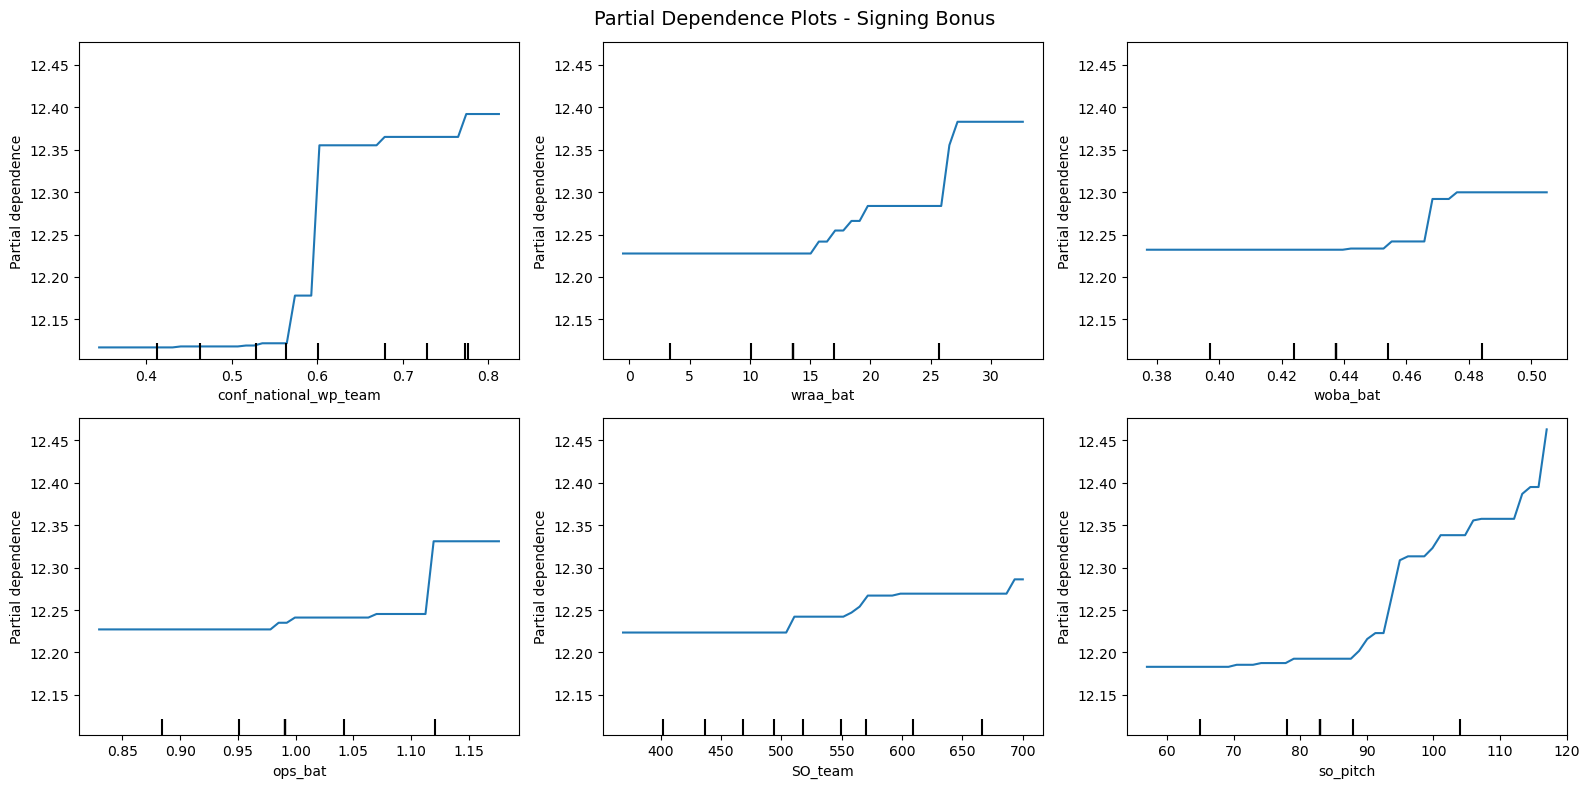

In [45]:
# Partial Dependence Plots - Signing Bonus Model
top_n = 6
importances_bonus = bonus_model.feature_importances_
top_indices_bonus = np.argsort(importances_bonus)[::-1][:top_n].tolist()

X_pdp_bonus = bonus_train[bonus_features].fillna(bonus_train[bonus_features].median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    bonus_model, X_pdp_bonus, features=top_indices_bonus,
    kind='average', ax=axes.flatten(),
    grid_resolution=50
)
fig.suptitle('Partial Dependence Plots - Signing Bonus', fontsize=14)
plt.tight_layout()
plt.show()

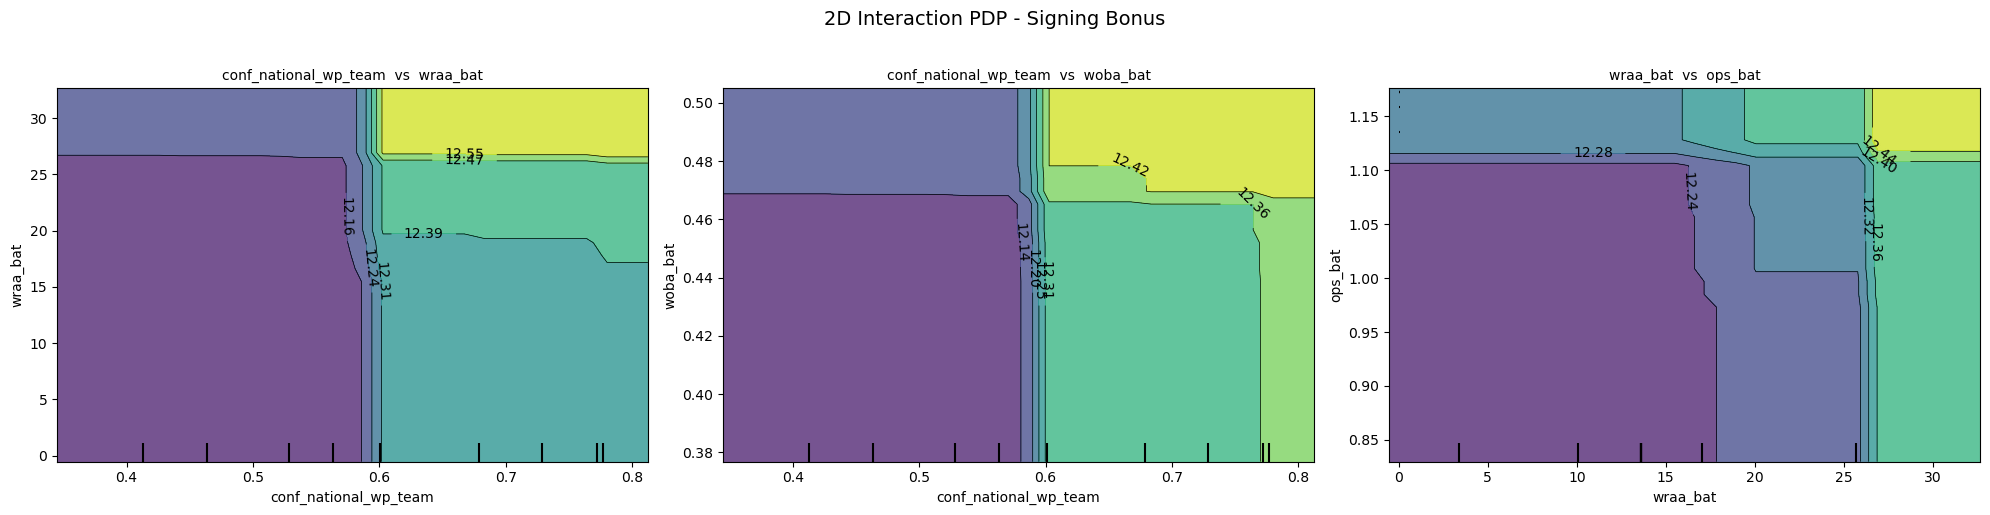

In [46]:
# 2D Interaction PDP - Signing Bonus Model
top_4_bonus = np.argsort(bonus_model.feature_importances_)[::-1][:4].tolist()
pairs_bonus = [(top_4_bonus[0], top_4_bonus[1]), (top_4_bonus[0], top_4_bonus[2]), (top_4_bonus[1], top_4_bonus[3])]
pair_labels_bonus = [(bonus_train[bonus_features].columns[a], bonus_train[bonus_features].columns[b]) for a, b in pairs_bonus]

X_pdp_bonus = bonus_train[bonus_features].fillna(bonus_train[bonus_features].median())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, pair, labels in zip(axes, pairs_bonus, pair_labels_bonus):
    disp = PartialDependenceDisplay.from_estimator(
        bonus_model, X_pdp_bonus, features=[pair],
        kind='average', ax=ax, grid_resolution=30
    )
    ax.set_title(f'{labels[0]}  vs  {labels[1]}', fontsize=10)
fig.suptitle('2D Interaction PDP - Signing Bonus', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Slot Value Prediction & Bonus/Slot Ratio

In [47]:
# Slot value model - same structure as signing bonus model
# Target: log(1 + api_pickValue * 1e6)
slot_df = draftedClean_df[draftedClean_df['api_pickValue'].notna()].copy()
slot_df['log_pickValue'] = np.log1p(slot_df['api_pickValue'] * 1e6)

print(f"Players with pick value data: {len(slot_df)} / {len(draftedClean_df)}")
print(f"Pick value range: ${slot_df['api_pickValue'].min()*1e6:,.0f} - ${slot_df['api_pickValue'].max()*1e6:,.0f}")

# Use same features as bonus model (excludes api_pickValue to avoid leakage)
slot_features = bonus_features

slot_train = slot_df[slot_df[year_col] < test_year]
slot_test = slot_df[slot_df[year_col] == test_year]

print(f"\nTrain: {len(slot_train)} players | Test: {len(slot_test)} players")

slot_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
    random_state=42, early_stopping_rounds=50, eval_metric='mae'
)
slot_model.fit(slot_train[slot_features], slot_train['log_pickValue'],
               eval_set=[(slot_test[slot_features], slot_test['log_pickValue'])], verbose=50)

slot_preds_log = slot_model.predict(slot_test[slot_features])
slot_preds_dollars = np.expm1(slot_preds_log)
slot_actual_dollars = np.expm1(slot_test['log_pickValue'].values)

mae_slot = mean_absolute_error(slot_actual_dollars, slot_preds_dollars)
r2_slot = r2_score(slot_actual_dollars, slot_preds_dollars)
corr_slot, p_slot = spearmanr(slot_actual_dollars, slot_preds_dollars)

print(f"\nSlot Value Model Results (Test Year: {test_year}, n={len(slot_test)}):")
print(f"  MAE:      ${mae_slot:,.0f}")
print(f"  R2:       {r2_slot:.3f}")
print(f"  Spearman: {corr_slot:.3f} (p={p_slot:.2e})")

Players with pick value data: 988 / 1433
Pick value range: $0 - $10,570,600

Train: 714 players | Test: 274 players
[0]	validation_0-mae:5.57789
[50]	validation_0-mae:5.43336
[100]	validation_0-mae:5.39528
[150]	validation_0-mae:5.37706
[200]	validation_0-mae:5.37156
[250]	validation_0-mae:5.36607
[300]	validation_0-mae:5.36376
[350]	validation_0-mae:5.36114
[400]	validation_0-mae:5.36261

Slot Value Model Results (Test Year: 2025, n=274):
  MAE:      $527,690
  R2:       0.389
  Spearman: 0.495 (p=2.48e-18)


In [48]:
# Bonus / Slot Ratio
# Match players that have BOTH signing bonus and pick value predictions
common_idx = bonus_test.index.intersection(slot_test.index)
ratio_df_src = draftedClean_df.loc[common_idx].copy()

ratio_bonus_preds = np.expm1(bonus_model.predict(ratio_df_src[bonus_features]))
ratio_slot_preds = np.expm1(slot_model.predict(ratio_df_src[slot_features]))

# Ratio: 1 = slot value, >1 = team valued highly, <1 = discount
bonus_slot_ratio = ratio_bonus_preds / np.maximum(ratio_slot_preds, 1)

ratio_df = pd.DataFrame({
    'name': ratio_df_src['nameascii'].values,
    'Predicted_Bonus': ratio_bonus_preds,
    'Predicted_Slot': ratio_slot_preds,
    'Bonus_Slot_Ratio': bonus_slot_ratio,
    'Actual_Pick': ratio_df_src['Pick'].values if 'Pick' in ratio_df_src.columns else range(len(ratio_df_src)),
}).sort_values('Actual_Pick').reset_index(drop=True)

print("Bonus / Slot Value Ratio (Test Year):")
print("  1.00 = got slot value | >1 = team valued highly | <1 = discount\n")

disp_ratio = ratio_df.head(30).copy()
disp_ratio['Predicted_Bonus'] = disp_ratio['Predicted_Bonus'].apply(lambda x: f"${x:,.0f}")
disp_ratio['Predicted_Slot'] = disp_ratio['Predicted_Slot'].apply(lambda x: f"${x:,.0f}")
disp_ratio['Bonus_Slot_Ratio'] = disp_ratio['Bonus_Slot_Ratio'].apply(lambda x: f"{x:.2f}")
display(disp_ratio)

print(f"\nRatio Summary:")
print(f"  Mean:   {bonus_slot_ratio.mean():.2f}")
print(f"  Median: {np.median(bonus_slot_ratio):.2f}")
print(f"  >1 (over-slot): {(bonus_slot_ratio > 1).sum()} players")
print(f"  <1 (under-slot): {(bonus_slot_ratio < 1).sum()} players")

Bonus / Slot Value Ratio (Test Year):
  1.00 = got slot value | >1 = team valued highly | <1 = discount



,name,Predicted_Bonus,Predicted_Slot,Bonus_Slot_Ratio,Actual_Pick
0,Kade Anderson,"$1,864,968","$3,562,862",0.52,3.0
1,Liam Doyle,"$2,116,834","$4,947,176",0.43,5.0
2,Aiva Arquette,"$757,270","$1,501,545",0.50,7.0
3,Jamie Arnold,"$763,802","$1,136,299",0.67,11.0
4,Gavin Kilen,"$543,953","$1,669,022",0.33,13.0
5,Kyson Witherspoon,"$733,855","$887,938",0.83,15.0
6,Marek Houston,"$419,414","$830,317",0.51,16.0
7,Ike Irish,"$872,327","$1,662,062",0.52,19.0
8,Andrew Fischer,"$2,043,346","$4,920,239",0.42,20.0
9,Jace LaViolette,"$293,026","$397,896",0.74,27.0



Ratio Summary:
  Mean:   0.50
  Median: 0.50
  >1 (over-slot): 1 players
  <1 (under-slot): 272 players


In [49]:
# Slot model feature importance
slot_imp = slot_model.get_booster().get_score(importance_type='gain')
slot_imp_df = pd.DataFrame({'Feature': list(slot_imp.keys()), 'Importance': list(slot_imp.values())}).sort_values('Importance', ascending=False)
print("Top 20 Slot Value Features:")
print(slot_imp_df.head(20).to_string(index=False))

Top 20 Slot Value Features:
              Feature  Importance
              SO_team    8.612741
             so_pitch    6.982204
              ops_bat    6.538393
            HRPG_team    6.012869
             wraa_bat    5.005092
        conf_rpi_team    4.596584
             bb/k_bat    4.272395
              HR_team    4.230381
            k/9_pitch    4.139385
conf_national_wp_team    4.050085
       conf_rank_team    3.537890
             wrc+_bat    3.437521
             k%_pitch    3.437364
       api_primaryPos    3.390322
               hr_bat    3.120843
            fip_pitch    3.116062
              w_pitch    3.085096
          k-bb%_pitch    3.057774
              slg_bat    2.918945
              wrc_bat    2.763663


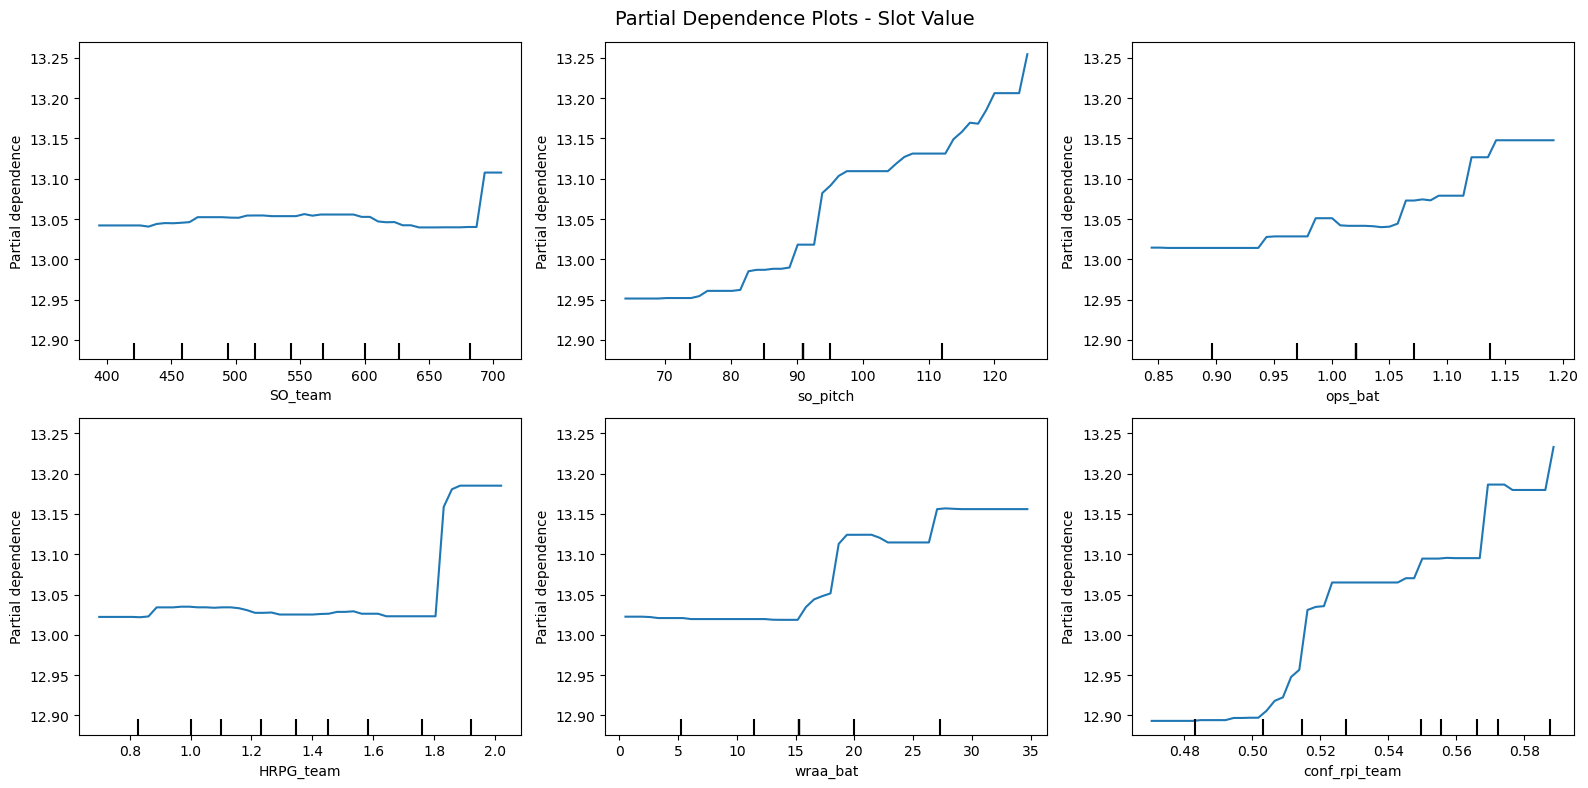

In [50]:
# Partial Dependence Plots - Slot Value Model
top_n = 6
importances_slot = slot_model.feature_importances_
top_indices_slot = np.argsort(importances_slot)[::-1][:top_n].tolist()

X_pdp_slot = slot_train[slot_features].fillna(slot_train[slot_features].median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    slot_model, X_pdp_slot, features=top_indices_slot,
    kind='average', ax=axes.flatten(),
    grid_resolution=50
)
fig.suptitle('Partial Dependence Plots - Slot Value', fontsize=14)
plt.tight_layout()
plt.show()

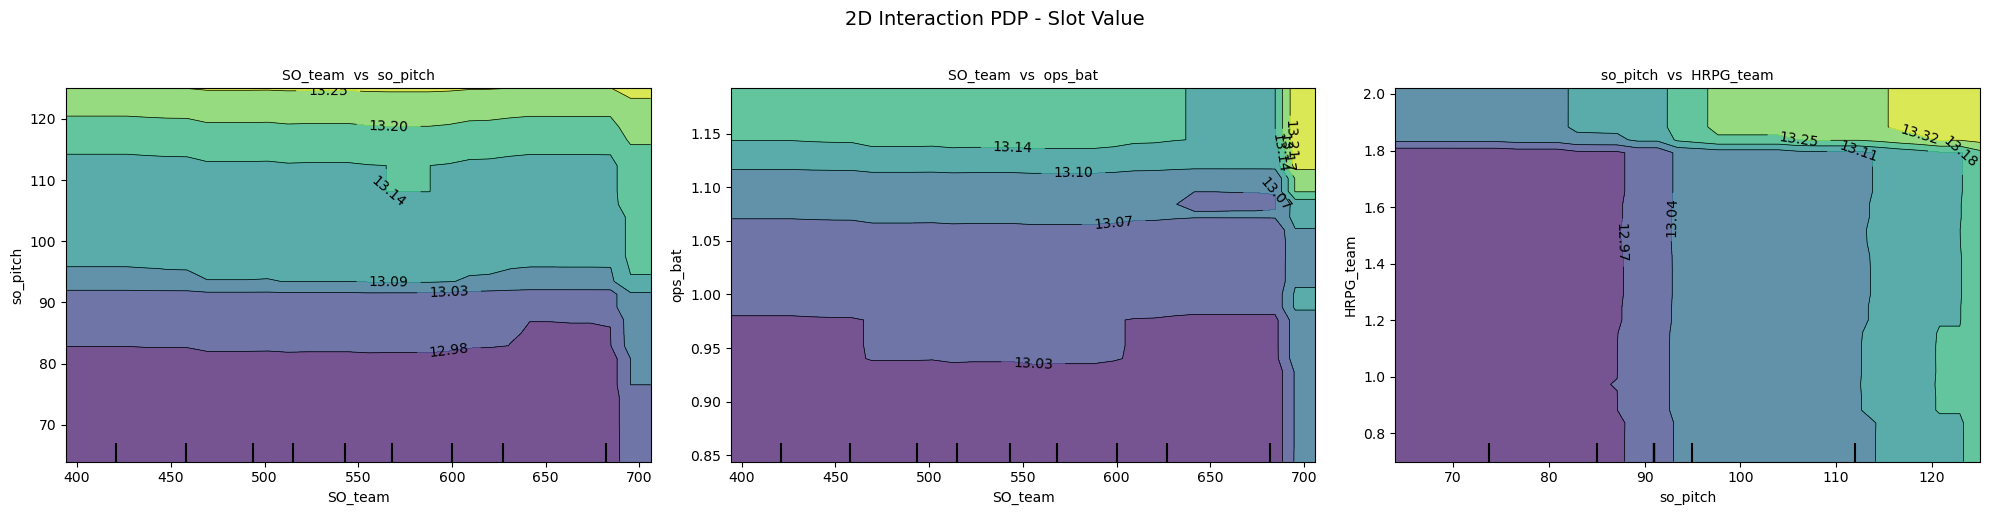

In [51]:
# 2D Interaction PDP - Slot Value Model
top_4_slot = np.argsort(slot_model.feature_importances_)[::-1][:4].tolist()
pairs_slot = [(top_4_slot[0], top_4_slot[1]), (top_4_slot[0], top_4_slot[2]), (top_4_slot[1], top_4_slot[3])]
pair_labels_slot = [(slot_train[slot_features].columns[a], slot_train[slot_features].columns[b]) for a, b in pairs_slot]

X_pdp_slot = slot_train[slot_features].fillna(slot_train[slot_features].median())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, pair, labels in zip(axes, pairs_slot, pair_labels_slot):
    disp = PartialDependenceDisplay.from_estimator(
        slot_model, X_pdp_slot, features=[pair],
        kind='average', ax=ax, grid_resolution=30
    )
    ax.set_title(f'{labels[0]}  vs  {labels[1]}', fontsize=10)
fig.suptitle('2D Interaction PDP - Slot Value', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Scouting Report Explainability Layer

For any player or custom stat line, the model now emits a **scouting report**:
a letter grade per dimension (Draft Probability and Draft Order Rank), a short
narrative, and ranked strengths/concerns showing which stats helped or hurt
the prediction.

Two explainers run side-by-side:

1. **SHAP TreeExplainer** — exact per-feature contribution to each prediction
   (gold-standard for XGBoost). Skipped automatically if `shap` is not installed.
2. **Importance × z-score** — XGBoost gain importance × `(player - train_median) / train_std`.
   No extra dependencies; works as a cross-check.

Scope: Draft Probability classifier (`draft_model`) and Draft Order Rank
regressor (`model_rank`). Bonus and slot models are out of scope here.


In [52]:
# Scouting Report -- explainer setup (run once)
# Builds the SHAP TreeExplainers (if shap is available), normalized feature
# importance dicts, training-set distributions for grading, a human label map,
# and a team-metadata frame re-loaded from the raw CSV (since cell 2 drops the
# team/Full Team Name/league_team columns from df to keep it numeric).

try:
    import shap
    _HAS_SHAP = True
except Exception as _e:
    _HAS_SHAP = False
    print(f"shap unavailable ({_e.__class__.__name__}) -- falling back to importance x z-score only.")
    print("To enable SHAP: !pip install shap   (and ensure numpy<2 for the rest of this env)")

from scipy.special import expit

# Threshold below which the rank/bonus/slot predictions are suppressed in the
# scouting report -- the rank model is trained only on drafted players, so for
# clearly-not-drafted profiles those numbers are unreliable extrapolation.
MIN_DRAFT_PROB_FOR_PICK_DETAILS = 0.25

# Re-load just the team-metadata columns from the raw CSV. df has these dropped
# (cell 2) so it stays numeric for the models; we need them for the scouting header.
_team_meta = pd.read_csv(
    'batting_pitching_combined.csv',
    delimiter=',',
    usecols=['nameascii', 'year', 'team', 'Full Team Name', 'league_team'],
)
_team_meta_idx = (
    _team_meta.dropna(subset=['nameascii', 'year'])
              .drop_duplicates(subset=['nameascii', 'year'], keep='last')
              .set_index(['nameascii', 'year'])
)

def _get_player_team_meta(nameascii, year):
    """Return {team, Full Team Name, league_team} for (nameascii, year), or Nones."""
    try:
        row = _team_meta_idx.loc[(nameascii, int(year))]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        return {
            'team': row.get('team'),
            'Full Team Name': row.get('Full Team Name'),
            'league_team': row.get('league_team'),
        }
    except (KeyError, TypeError):
        return {'team': None, 'Full Team Name': None, 'league_team': None}

# Snapshot the *_team stat columns at setup time -- the Carbon Tracking cell at
# the end of the notebook reassigns df = pd.read_csv(emissions.csv), so any later
# call into get_team_stats would fail with KeyError on df['nameascii']. Build a
# frozen (team_lower, year) -> {*_team col: value} lookup right here, while df
# still points at the player frame.
_team_stat_cols = [c for c in df.columns if c.endswith('_team')]
_TEAM_STATS_BY_TEAM_YEAR = {}
for (_tc, _yr), _grp in (_team_meta
                         .dropna(subset=['nameascii', 'year', 'team'])
                         .groupby(['team', 'year'])):
    _na = _grp['nameascii'].iloc[0]
    _m = df[(df['nameascii'] == _na) & (df[year_col] == _yr)]
    if _m.empty:
        continue
    _row = _m.iloc[0]
    _TEAM_STATS_BY_TEAM_YEAR[(str(_tc).lower(), int(_yr))] = {
        col: _row[col] for col in _team_stat_cols
    }

# Training-set summary stats on the same split used for train_medians.
train_stds = df[df[year_col] < test_year].std(numeric_only=True)

# TreeExplainers (operate on raw model objects; very fast for XGBoost).
expl_draft = shap.TreeExplainer(draft_model) if _HAS_SHAP else None
expl_rank  = shap.TreeExplainer(model_rank)  if _HAS_SHAP else None

# Normalized gain-importance dicts (sum to 1.0).
def _normed_importance(model):
    raw = model.get_booster().get_score(importance_type='gain')
    total = sum(raw.values()) or 1.0
    return {k: v / total for k, v in raw.items()}

imp_draft = _normed_importance(draft_model)
imp_rank  = _normed_importance(model_rank)

# Training distributions for letter-grading the predictions.
_train_mask     = df[year_col] < test_year
_train_X_cls    = df.loc[_train_mask, features]
_train_drafted  = draftedClean_df[draftedClean_df[year_col] < test_year]
_train_X_rank   = _train_drafted[pick_features]
_train_draft_probs = draft_model.predict_proba(_train_X_cls)[:, 1]
_train_rank_preds  = model_rank.predict(_train_X_rank)

# Human-readable labels (raw column name -> short label).
FEATURE_LABELS = {
    'role': 'Role',
    # Pitching
    'era_pitch': 'ERA',         'fip_pitch': 'FIP',
    'k/9_pitch': 'K/9',         'bb/9_pitch': 'BB/9',
    'k/bb_pitch': 'K/BB',       'whip_pitch': 'WHIP',
    'k%_pitch': 'K%',           'bb%_pitch': 'BB%',
    'k-bb%_pitch': 'K-BB%',     'ip_pitch': 'IP',
    'so_pitch': 'SO',           'bb_pitch': 'BB (pitch)',
    'h_pitch': 'H allowed',     'hr_pitch': 'HR allowed',
    'hr/9_pitch': 'HR/9',       'er_pitch': 'ER',
    'r_pitch': 'R allowed',     'avg_pitch': 'BA against',
    'babip_pitch': 'BABIP-against', 'lob%_pitch': 'LOB%',
    'e-f_pitch': 'ERA-FIP',     'sv_pitch': 'SV',
    'g_pitch': 'G (pitch)',     'gs_pitch': 'GS',
    'w_pitch': 'W',             'l_pitch': 'L',
    'tbf_pitch': 'TBF',         'hbp_pitch': 'HBP (pitch)',
    'wp_pitch': 'WP',           'bk_pitch': 'BK',
    'cg_pitch': 'CG',           'sho_pitch': 'SHO',
    # Batting
    'avg_bat': 'AVG',  'obp_bat': 'OBP',  'slg_bat': 'SLG',  'ops_bat': 'OPS',
    'iso_bat': 'ISO',  'woba_bat': 'wOBA','wrc+_bat': 'wRC+','wrc_bat': 'wRC',
    'wraa_bat': 'wRAA','hr_bat': 'HR',    'rbi_bat': 'RBI',  'r_bat': 'R',
    'h_bat': 'H',      '2b_bat': '2B',    '3b_bat': '3B',    '1b_bat': '1B',
    'bb%_bat': 'BB% (bat)',  'k%_bat': 'K% (bat)',
    'bb_bat': 'BB (bat)',    'so_bat': 'SO (bat)',
    'sb_bat': 'SB',          'cs_bat': 'CS',
    'babip_bat': 'BABIP',    'spd_bat': 'Spd',
    'g_bat': 'G (bat)',      'ab_bat': 'AB',  'pa_bat': 'PA',
    'hbp_bat': 'HBP (bat)',  'sf_bat': 'SF',  'sh_bat': 'SH',  'gdp_bat': 'GDP',
    'bb/k_bat': 'BB/K',      'wsb_bat': 'wSB',
}


def get_team_stats(team, team_year):
    """Return all *_team stats for a (team, team_year) pair, plus resolved metadata.

    Strict: `team` matches the raw-CSV `team` column case-insensitively (e.g. 'LSU',
    'USF'); `team_year` must exactly match `year`. Reads from the setup-time
    snapshot `_TEAM_STATS_BY_TEAM_YEAR` (not from df), so it stays correct even
    after the Carbon Tracking cell reassigns df to the emissions frame.

    Returns a flat dict for predict_from_stats(..., team_stats_dict=...). The
    `_resolved_*` keys carry display metadata and are ignored by the predictor.

    Raises ValueError if no match is found.
    """
    if team is None or team_year is None:
        raise ValueError("get_team_stats requires both `team` and `team_year`.")
    key = (str(team).lower(), int(team_year))
    stats = _TEAM_STATS_BY_TEAM_YEAR.get(key)
    if stats is None:
        codes = sorted({k[0].upper() for k in _TEAM_STATS_BY_TEAM_YEAR})[:25]
        raise ValueError(
            f"No rows found for team={team!r} year={team_year}. "
            f"Try one of (first 25 codes): {codes}. "
            f"Full list: sorted({{k[0].upper() for k in _TEAM_STATS_BY_TEAM_YEAR}})."
        )

    mask = (_team_meta['team'].astype(str).str.lower() == str(team).lower()) & (_team_meta['year'] == team_year)
    meta = _team_meta[mask].iloc[0]

    out = dict(stats)
    out['_resolved_team'] = str(meta['team']).upper()
    out['_resolved_team_year'] = int(team_year)
    full_name = meta.get('Full Team Name')
    out['_resolved_full_name'] = str(full_name).title() if pd.notna(full_name) else out['_resolved_team']
    league = meta.get('league_team')
    out['_resolved_conference'] = str(league) if pd.notna(league) else None
    return out


print("Explainer setup loaded.")
print(f"  SHAP available:        {_HAS_SHAP}")
print(f"  draft features:        {len(features)}    rank features: {len(pick_features)}")
print(f"  train baseline draft%: {_train_draft_probs.mean()*100:.1f}%")
print(f"  train rank dist:       median={np.median(_train_rank_preds):.1f}  "
      f"p10={np.percentile(_train_rank_preds,10):.1f}  p90={np.percentile(_train_rank_preds,90):.1f}")
print(f"  pick-detail threshold: {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}% draft prob (below this, rank/bonus/slot are hidden)")
print(f"  team-meta rows loaded: {len(_team_meta):,}  (re-loaded from CSV; df has these columns dropped)")
print(f"  team-stats snapshot:   {len(_TEAM_STATS_BY_TEAM_YEAR):,} (team, year) pairs cached (survives df mutations)")
print(f"  get_team_stats() ready -- usage: get_team_stats('LSU', 2024)")


Explainer setup loaded.
  SHAP available:        True
  draft features:        118    rank features: 123
  train baseline draft%: 27.0%
  train rank dist:       median=149.5  p10=64.0  p90=216.2
  pick-detail threshold: 25% draft prob (below this, rank/bonus/slot are hidden)
  team-meta rows loaded: 16,728  (re-loaded from CSV; df has these columns dropped)
  team-stats snapshot:   1,475 (team, year) pairs cached (survives df mutations)
  get_team_stats() ready -- usage: get_team_stats('LSU', 2024)


In [53]:
# Scouting Report -- core functions
#   _explain_one(row, kind)  -> per-feature contribution records
#   _grade(percentile)       -> letter grade
#   scouting_report(row, draft_prob, rank_pred, name=..., team=..., conference=...)

def _label(feat):
    return FEATURE_LABELS.get(feat, feat)

def _fmt(value):
    if value is None: return '-'
    if isinstance(value, float):
        if np.isnan(value) or np.isinf(value): return '-'
        return f"{value:.3f}" if abs(value) < 10 else f"{value:.1f}"
    return str(value)

def _rec_score(r):
    """Single sortable score per record: prefer SHAP, fall back to imp_z."""
    for k in ('shap_pct', 'shap_picks'):
        if r[k] is not None and not (isinstance(r[k], float) and np.isnan(r[k])):
            return r[k]
    return r['imp_z']

def _explain_one(row_series, model_kind):
    """Return contribution records sorted strengths-first (positive = good for the player)."""
    if model_kind == 'draft':
        feat_list, imp, explainer, sign_flip = features, imp_draft, expl_draft, 1.0
    elif model_kind == 'rank':
        feat_list, imp, explainer, sign_flip = pick_features, imp_rank, expl_rank, -1.0
    else:
        raise ValueError(model_kind)

    vals = row_series.reindex(feat_list).values
    x_df = pd.DataFrame([vals], columns=feat_list)

    shap_vals = None
    base = 0.0
    log_pred = 0.0
    if explainer is not None:
        sv = explainer.shap_values(x_df)
        if isinstance(sv, list):
            sv = sv[1]
        shap_vals = sv[0]
        ev = explainer.expected_value
        try:
            base = float(ev) if not hasattr(ev, '__len__') else float(ev[1] if len(ev) > 1 else ev[0])
        except (TypeError, ValueError):
            base = float(np.asarray(ev).ravel()[-1])
        log_pred = base + float(np.nansum(shap_vals))

    recs = []
    for i, feat in enumerate(feat_list):
        v = row_series.get(feat)
        if v is None or (isinstance(v, float) and pd.isna(v)):
            continue
        med = train_medians.get(feat, np.nan)
        std = train_stds.get(feat, np.nan)
        imp_z = 0.0 if (pd.isna(std) or std == 0) else imp.get(feat, 0.0) * float((v - med) / std) * sign_flip

        shap_pct = shap_picks = None
        if shap_vals is not None:
            s = float(shap_vals[i])
            if model_kind == 'draft':
                shap_pct = (expit(log_pred) - expit(log_pred - s)) * 100.0
            else:
                shap_picks = s * sign_flip

        recs.append({
            'feature': feat, 'label': _label(feat),
            'value': v, 'median': med,
            'shap_pct': shap_pct, 'shap_picks': shap_picks,
            'imp_z': imp_z,
        })

    recs.sort(key=_rec_score, reverse=True)
    return recs


def _draft_grade(draft_prob):
    """Map raw draft probability directly to a letter grade.

    Absolute thresholds (not training percentiles), so 0% -> F instead of D+:
        >= 90% A+   >= 80% A    >= 70% A-
        >= 60% B+   >= 50% B    >= 40% B-
        >= 30% C+   >= 20% C    >= 10% C-
        >=  5% D+   >=  2% D    >=  1% D-
        <   1% F
    Returns (letter, training_pct) -- training_pct is still computed so the report
    can show it as an auxiliary stat in parentheses.
    """
    p_pct = draft_prob * 100
    bands = [(90,'A+'),(80,'A'),(70,'A-'),(60,'B+'),(50,'B'),(40,'B-'),
             (30,'C+'),(20,'C'),(10,'C-'),(5,'D+'),(2,'D'),(1,'D-')]
    letter = 'F'
    for thresh, lbl in bands:
        if p_pct >= thresh:
            letter = lbl
            break
    train_pct = float((_train_draft_probs <= draft_prob).mean() * 100)
    return letter, train_pct


def _rank_grade(rank_pred):
    pct = float((_train_rank_preds >= rank_pred).mean() * 100)
    bins = [(95,'A+'),(88,'A'),(80,'A-'),(72,'B+'),(62,'B'),(54,'B-'),
            (46,'C+'),(38,'C'),(30,'C-'),(22,'D+'),(15,'D'),(8,'D-')]
    letter = 'F'
    for t, lbl in bins:
        if pct >= t:
            letter = lbl
            break
    return letter, pct


def _narrative(draft_letter, top_strength, top_concern, rank_pred, show_rank):
    band = {
        'A+':'a top-of-the-board profile', 'A':'an elite first-round projection',
        'A-':'a strong first-round projection', 'B+':'a comp-/2nd-round caliber projection',
        'B':'a solid day-one/day-two projection', 'B-':'a mid-round projection',
        'C+':'a back-half day-two projection', 'C':'a day-three / fringe projection',
        'C-':'a fringe-draftable profile', 'D+':'a long-shot draft profile',
        'D':'an undrafted-leaning profile', 'D-':'a UDFA-leaning profile',
        'F':'a clearly undrafted-leaning profile',
    }.get(draft_letter, 'a draftable profile')
    rank_phrase = f" (~pick {int(round(rank_pred))})" if show_rank else ""
    parts = [f"The model sees {band}{rank_phrase}."]
    if top_strength is not None:
        parts.append(f"Driven by {top_strength['label']} ({_fmt(top_strength['value'])} vs {_fmt(top_strength['median'])} median).")
    if top_concern is not None:
        parts.append(f"Main red flag: {top_concern['label']} ({_fmt(top_concern['value'])} vs {_fmt(top_concern['median'])} median).")
    return " ".join(parts)


def scouting_report(row_series, draft_prob, rank_pred, name=None, team=None, conference=None, top_n=5):
    """Print the scouting report block.

    row_series: pandas Series indexed by feature name (player or custom row).
    team/conference: optional strings shown right under the player name.
    """
    name = name or 'Custom Stat Line'
    show_rank = draft_prob >= MIN_DRAFT_PROB_FOR_PICK_DETAILS

    d_letter, d_pct = _draft_grade(draft_prob)
    if show_rank:
        r_letter, r_pct = _rank_grade(rank_pred)

    draft_recs = _explain_one(row_series, 'draft')
    rank_recs  = _explain_one(row_series, 'rank') if show_rank else []

    strengths = [r for r in draft_recs if _rec_score(r) > 0][:top_n]
    concerns  = [r for r in reversed(draft_recs) if _rec_score(r) < 0][:top_n]
    top_s = strengths[0] if strengths else None
    top_c = concerns[0] if concerns else None

    sep = '=' * 64
    print(f"\n{sep}")
    print(f"  Scouting Report: {name}")
    if team or conference:
        parts = []
        if team:       parts.append(f"Team: {team}")
        if conference: parts.append(f"Conference: {conference}")
        print(f"  {'   '.join(parts)}")
    print(sep)
    print(f"  Draft Grade: {d_letter}   (P[draft]={draft_prob*100:.1f}%, "
          f"{d_pct:.0f}th pct of training preds)")
    if show_rank:
        print(f"  Rank  Grade: {r_letter}   (predicted pick ~{int(round(rank_pred))}, "
              f"{r_pct:.0f}th pct of training preds)")
    else:
        print(f"  Rank  Grade: -    (suppressed: draft prob < {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}%)")
    print('-' * 64)
    print(f"  Take: {_narrative(d_letter, top_s, top_c, rank_pred, show_rank)}")

    def _print_block(title, recs, arrow):
        print()
        header = "    feature             value      vs median"
        if _HAS_SHAP: header += "      d-prob"
        header += "    imp x z"
        print(f"  {title}")
        print(header)
        if not recs:
            print("    (none)")
            return
        for r in recs:
            shap_part = ''
            if _HAS_SHAP and r['shap_pct'] is not None:
                shap_part = f"   {r['shap_pct']:+6.2f}%"
            elif _HAS_SHAP:
                shap_part = '          -'
            imp_part = f"   {r['imp_z']:+7.3f}"
            print(f"    {arrow} {r['label']:<16s}  {_fmt(r['value']):>8s}  "
                  f"(vs {_fmt(r['median']):>7s}){shap_part}{imp_part}")

    _print_block(f"Top {len(strengths)} STRENGTHS (boost draft stock)", strengths, '^')
    _print_block(f"Top {len(concerns)} CONCERNS  (drag it down)",        concerns,  'v')

    if show_rank:
        r_str = [r for r in rank_recs if _rec_score(r) > 0][:3]
        r_con = [r for r in reversed(rank_recs) if _rec_score(r) < 0][:3]
        print()
        print("  Rank-model cross-check (which features improve / hurt predicted pick):")
        print(f"    + improves pick: {', '.join(r['label'] for r in r_str) or '(none)'}")
        print(f"    - hurts pick:    {', '.join(r['label'] for r in r_con) or '(none)'}")
    print(sep)


---
## Player Lookup by Name

Fuzzy-match a player and show stats, draft probability, predicted college order, and predicted signing bonus.

In [54]:
from difflib import get_close_matches

train_medians = df[df[year_col] < test_year].median(numeric_only=True)

def _format_team_display(team_code, full_team_name):
    """Title-case the full team name; append the short code in parens if both exist."""
    has_full = pd.notna(full_team_name) and str(full_team_name).strip()
    has_code = pd.notna(team_code) and str(team_code).strip()
    if has_full and has_code:
        return f"{str(full_team_name).title()} ({str(team_code).upper()})"
    if has_full:
        return str(full_team_name).title()
    if has_code:
        return str(team_code).upper()
    return None

def lookup_player(name_query, year=None, explain=True):
    candidates = df if year is None else df[df[year_col] == year]
    names = candidates['nameascii'].dropna().unique().tolist()
    matches = get_close_matches(name_query, names, n=5, cutoff=0.4)
    if not matches:
        print(f"No match found for '{name_query}'"); return None

    player = candidates[candidates['nameascii'] == matches[0]].sort_values(year_col, ascending=False).iloc[0]
    role_name = {0: 'Pitcher', 1: 'Batter', 2: 'Both'}.get(player['role'], '?')

    # team/Full Team Name/league_team were dropped from df in cell 2 to keep
    # df numeric; re-load them from _team_meta (built in cell 56 from the CSV).
    team_meta = _get_player_team_meta(player['nameascii'], int(player[year_col]))
    team_display = _format_team_display(team_meta['team'], team_meta['Full Team Name'])
    league = team_meta['league_team']
    conf_display = str(league) if pd.notna(league) else None

    print(f"{'='*60}")
    print(f"Player: {player['nameascii']}  |  Year: {int(player[year_col])}  |  Role: {role_name}")
    if team_display or conf_display:
        bits = []
        if team_display: bits.append(f"Team: {team_display}")
        if conf_display: bits.append(f"Conference: {conf_display}")
        print('  ' + '   '.join(bits))
    print(f"{'='*60}")

    if not pd.isna(player.get('api_height')):
        ft, inch = int(player['api_height'] // 12), int(player['api_height'] % 12)
        print(f"Height: {ft}'{inch}\"  |  Weight: {int(player.get('api_weight', 0))} lbs")
    pos_rev = {1:'C', 2:'SS', 3:'2B', 4:'3B', 5:'CF', 6:'LF', 7:'RF', 8:'IF', 9:'1B', 10:'OF', 11:'DH', 12:'P', 13:'TWP'}
    if not pd.isna(player.get('api_primaryPos')):
        print(f"Position: {pos_rev.get(int(player['api_primaryPos']), '?')}")

    print(f"\n--- Key Stats ---")
    if player['role'] in [0, 2]:
        for s in ['era_pitch', 'fip_pitch', 'k/9_pitch', 'bb/9_pitch', 'whip_pitch', 'ip_pitch', 'so_pitch']:
            if not pd.isna(player.get(s)): print(f"  {s}: {player[s]:.2f}")
    if player['role'] in [1, 2]:
        for s in ['avg_bat', 'ops_bat', 'hr_bat', 'wrc+_bat', 'woba_bat', 'slg_bat', 'bb%_bat', 'k%_bat']:
            if not pd.isna(player.get(s)):
                v = player[s]; print(f"  {s}: {v:.3f}" if isinstance(v, float) and v < 10 else f"  {s}: {v:.1f}")

    cls_df = pd.DataFrame([player.reindex(features).values], columns=features)
    draft_prob = draft_model.predict_proba(cls_df)[0][1]
    rank_df = pd.DataFrame([player.reindex(pick_features).values], columns=pick_features)
    rank_pred = model_rank.predict(rank_df)[0]
    bonus_df_in = pd.DataFrame([player.reindex(bonus_features).values], columns=bonus_features)
    bonus_pred = np.expm1(bonus_model.predict(bonus_df_in)[0])

    slot_df_in = pd.DataFrame([player.reindex(slot_features).values], columns=slot_features)
    slot_pred = np.expm1(slot_model.predict(slot_df_in)[0])
    ratio = bonus_pred / max(slot_pred, 1)

    pct_pred = model_rank_pct.predict(rank_df)[0]

    print(f"\n--- Predictions ---")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    if draft_prob >= MIN_DRAFT_PROB_FOR_PICK_DETAILS:
        print(f"Predicted College Draft Order: ~{int(round(rank_pred))}")
        print(f"Predicted College Draft Pct: {pct_pred*100:.1f}%")
        print(f"Predicted Signing Bonus: ${bonus_pred:,.0f}")
        print(f"Predicted Slot Value: ${slot_pred:,.0f}")
        print(f"Bonus/Slot Ratio: {ratio:.2f}")
    else:
        print(f"Predicted draft order / signing bonus / slot value suppressed "
              f"(draft prob {draft_prob*100:.1f}% < {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}% threshold -- "
              f"the rank/bonus/slot models are trained only on drafted players and would be extrapolating).")

    if not pd.isna(player.get('Pick')):
        print(f"\n--- Actual ---")
        print(f"Pick: {int(player['Pick'])} (Round {int(player.get('Round', 0))})")
        if not pd.isna(player.get('College_Draft_Order')): print(f"College Order: {int(player['College_Draft_Order'])}")
        if not pd.isna(player.get('api_signingBonus')): print(f"Signing Bonus: ${player['api_signingBonus']*1e6:,.0f}")
    if len(matches) > 1: print(f"\nOther matches: {matches[1:]}")

    if explain and 'scouting_report' in globals():
        scouting_report(player, draft_prob, rank_pred,
                        name=player['nameascii'],
                        team=team_display,
                        conference=conf_display)

    return player

print("lookup_player() defined. Usage: lookup_player('Jace LaViolette')")


lookup_player() defined. Usage: lookup_player('Jace LaViolette')


In [55]:
lookup_player('Jace LaViolette')

Player: Jace LaViolette  |  Year: 2025  |  Role: Batter
  Team: Texas Aandm University (TA&M)   Conference: SEC

--- Key Stats ---
  avg_bat: 0.258
  ops_bat: 1.003
  hr_bat: 18.0
  wrc+_bat: 119.7
  woba_bat: 0.435
  slg_bat: 0.576
  bb%_bat: 0.218
  k%_bat: 0.252

--- Predictions ---
Draft Probability: 99.5%
Predicted College Draft Order: ~104
Predicted College Draft Pct: 41.0%
Predicted Signing Bonus: $293,026
Predicted Slot Value: $402,654
Bonus/Slot Ratio: 0.73

--- Actual ---
Pick: 27 (Round 1)

Other matches: ['Jack Colette', 'Jack Little', 'Jared Viertel', 'Wil LaFollette']

  Scouting Report: Jace LaViolette
  Team: Texas Aandm University (TA&M)   Conference: SEC
  Draft Grade: A+   (P[draft]=99.5%, 97th pct of training preds)
  Rank  Grade: B+   (predicted pick ~104, 75th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top-of-the-board profile (~pick 104). Driven by conf_rpi_team (0.586 vs 0.492 median). Main re

age                                 21.0
nameascii                Jace LaViolette
year                                2025
w_pitch                              NaN
l_pitch                              NaN
era_pitch                            NaN
g_pitch                              NaN
gs_pitch                             NaN
cg_pitch                             NaN
sho_pitch                            NaN
sv_pitch                             NaN
ip_pitch                             NaN
tbf_pitch                            NaN
h_pitch                              NaN
r_pitch                              NaN
er_pitch                             NaN
hr_pitch                             NaN
bb_pitch                             NaN
hbp_pitch                            NaN
wp_pitch                             NaN
bk_pitch                             NaN
so_pitch                             NaN
k/9_pitch                            NaN
bb/9_pitch                           NaN
k/bb_pitch      

In [56]:
lookup_player('Kade Anderson')

Player: Kade Anderson  |  Year: 2025  |  Role: Pitcher
  Team: Louisiana State University (LSU)   Conference: SEC

--- Key Stats ---
  era_pitch: 3.18
  fip_pitch: 3.42
  k/9_pitch: 13.61
  bb/9_pitch: 2.65
  whip_pitch: 1.06
  ip_pitch: 119.00
  so_pitch: 180.00

--- Predictions ---
Draft Probability: 100.0%
Predicted College Draft Order: ~13
Predicted College Draft Pct: 5.1%
Predicted Signing Bonus: $2,177,599
Predicted Slot Value: $4,559,182
Bonus/Slot Ratio: 0.48

--- Actual ---
Pick: 3 (Round 1)

Other matches: ['Nate Anderson', 'Kaden Amundson', 'Drake Anderson', 'Chase Anderson']

  Scouting Report: Kade Anderson
  Team: Louisiana State University (LSU)   Conference: SEC
  Draft Grade: A+   (P[draft]=100.0%, 100th pct of training preds)
  Rank  Grade: A+   (predicted pick ~13, 100th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top-of-the-board profile (~pick 13). Driven by SO (180.0 vs 55.0 median). Main red fla

age                               20.0
nameascii                Kade Anderson
year                              2025
w_pitch                           12.0
l_pitch                            1.0
era_pitch                     3.176471
g_pitch                           19.0
gs_pitch                          19.0
cg_pitch                           2.0
sho_pitch                          2.0
sv_pitch                           0.0
ip_pitch                         119.0
tbf_pitch                        481.0
h_pitch                           91.0
r_pitch                           44.0
er_pitch                          42.0
hr_pitch                          16.0
bb_pitch                          35.0
hbp_pitch                          5.0
wp_pitch                           5.0
bk_pitch                           0.0
so_pitch                         180.0
k/9_pitch                    13.613445
bb/9_pitch                    2.647059
k/bb_pitch                    5.142857
hr/9_pitch               

In [57]:
lookup_player('alex mccoy')

Player: Alex McCoy  |  Year: 2024  |  Role: Batter
  Team: Hofstra University (HOF)   Conference: CAA

--- Key Stats ---
  avg_bat: 0.306
  ops_bat: 0.893
  hr_bat: 11.0
  wrc+_bat: 106.5
  woba_bat: 0.400
  slg_bat: 0.509
  bb%_bat: 0.078
  k%_bat: 0.192

--- Predictions ---
Draft Probability: 4.6%
Predicted draft order / signing bonus / slot value suppressed (draft prob 4.6% < 25% threshold -- the rank/bonus/slot models are trained only on drafted players and would be extrapolating).

Other matches: ['Callen Nuccio', 'Kyle McCoy', 'Jake McCoy', 'Caleb Floyd']

  Scouting Report: Alex McCoy
  Team: Hofstra University (HOF)   Conference: CAA
  Draft Grade: D   (P[draft]=4.6%, 51th pct of training preds)
  Rank  Grade: -    (suppressed: draft prob < 25%)
----------------------------------------------------------------
  Take: The model sees an undrafted-leaning profile. Driven by SB (22.0 vs 4.000 median). Main red flag: HA_team (563.0 vs 508.0 median).

  Top 5 STRENGTHS (boost draft s

age                            22.0
nameascii                Alex McCoy
year                           2024
w_pitch                         NaN
l_pitch                         NaN
era_pitch                       NaN
g_pitch                         NaN
gs_pitch                        NaN
cg_pitch                        NaN
sho_pitch                       NaN
sv_pitch                        NaN
ip_pitch                        NaN
tbf_pitch                       NaN
h_pitch                         NaN
r_pitch                         NaN
er_pitch                        NaN
hr_pitch                        NaN
bb_pitch                        NaN
hbp_pitch                       NaN
wp_pitch                        NaN
bk_pitch                        NaN
so_pitch                        NaN
k/9_pitch                       NaN
bb/9_pitch                      NaN
k/bb_pitch                      NaN
hr/9_pitch                      NaN
k%_pitch                        NaN
bb%_pitch                   

In [58]:
lookup_player('cooper clark')

Player: Cooper Clark  |  Year: 2024  |  Role: Pitcher
  Team: Campbell University (CAM)   Conference: CAA

--- Key Stats ---
  era_pitch: 7.71
  fip_pitch: 5.55
  k/9_pitch: 8.24
  bb/9_pitch: 2.63
  whip_pitch: 1.58
  ip_pitch: 51.10
  so_pitch: 47.00

--- Predictions ---
Draft Probability: 11.5%
Predicted draft order / signing bonus / slot value suppressed (draft prob 11.5% < 25% threshold -- the rank/bonus/slot models are trained only on drafted players and would be extrapolating).

Other matches: ['Cooper Blauser', 'Cooper Mrowka', 'Cooper Thacker', 'Cooper Katskee']

  Scouting Report: Cooper Clark
  Team: Campbell University (CAM)   Conference: CAA
  Draft Grade: C-   (P[draft]=11.5%, 60th pct of training preds)
  Rank  Grade: -    (suppressed: draft prob < 25%)
----------------------------------------------------------------
  Take: The model sees a fringe-draftable profile. Driven by ERA-FIP (2.159 vs -0.363 median). Main red flag: SO (47.0 vs 55.0 median).

  Top 5 STRENGTHS (

age                               NaN
nameascii                Cooper Clark
year                             2024
w_pitch                           4.0
l_pitch                           1.0
era_pitch                    7.714286
g_pitch                          13.0
gs_pitch                         11.0
cg_pitch                          0.0
sho_pitch                         0.0
sv_pitch                          0.0
ip_pitch                         51.1
tbf_pitch                       242.0
h_pitch                          66.0
r_pitch                          47.0
er_pitch                         44.0
hr_pitch                          7.0
bb_pitch                         15.0
hbp_pitch                        11.0
wp_pitch                          8.0
bk_pitch                          0.0
so_pitch                         47.0
k/9_pitch                     8.24026
bb/9_pitch                    2.62987
k/bb_pitch                   3.133333
hr/9_pitch                   1.227273
k%_pitch    

---
## Custom Stats Input

Predict draft probability, college order, and signing bonus from custom stat values.

In [59]:
PITCHER_TEMPLATE = {
    'era_pitch': 3.50, 'fip_pitch': 3.40, 'ip_pitch': 90.0,
    'so_pitch': 100, 'bb_pitch': 25, 'h_pitch': 75, 'hr_pitch': 5,
    'g_pitch': 15, 'gs_pitch': 14, 'w_pitch': 8, 'l_pitch': 3,
    'k/9_pitch': 10.0, 'bb/9_pitch': 2.5, 'k/bb_pitch': 4.0, 'whip_pitch': 1.10,
    'k%_pitch': 0.28, 'bb%_pitch': 0.07, 'k-bb%_pitch': 0.21,
    'avg_pitch': 0.230, 'babip_pitch': 0.290, 'lob%_pitch': 0.72,
    'hr/9_pitch': 0.5, 'e-f_pitch': 0.5, 'sv_pitch': 0, 'tbf_pitch': 350,
    'r_pitch': 40, 'er_pitch': 35, 'hbp_pitch': 5, 'wp_pitch': 3, 'bk_pitch': 0, 'cg_pitch': 0, 'sho_pitch': 0,
}
BATTER_TEMPLATE = {
    'avg_bat': 0.300, 'ops_bat': 0.900, 'hr_bat': 15,
    'wrc+_bat': 130, 'woba_bat': 0.400, 'slg_bat': 0.520, 'obp_bat': 0.400,
    'bb%_bat': 0.12, 'k%_bat': 0.15, 'iso_bat': 0.200,
    'g_bat': 55, 'ab_bat': 200, 'pa_bat': 240, 'h_bat': 60,
    '1b_bat': 35, '2b_bat': 15, '3b_bat': 2, 'r_bat': 40,
    'rbi_bat': 45, 'bb_bat': 30, 'so_bat': 35, 'hbp_bat': 5,
    'sf_bat': 3, 'sh_bat': 1, 'gdp_bat': 3, 'sb_bat': 10, 'cs_bat': 2,
    'spd_bat': 5.0, 'babip_bat': 0.330, 'wsb_bat': 1.0, 'wrc_bat': 40.0, 'wraa_bat': 15.0, 'bb/k_bat': 0.8,
}

def predict_from_stats(role, age, stats_dict, team_stats_dict=None,
                       team=None, team_year=None, explain=True, name=None):
    """Predict draft outcomes from a custom stat line.

    `age` is accepted as a positional argument for backward compatibility with
    V7 callers, but V8 models do not use age -- the value is silently dropped
    before the row is built. Any 'age' key in stats_dict is also ignored.

    Optional kwargs:
      team, team_year -- when both are given AND team_stats_dict is None,
        get_team_stats(team, team_year) is called to auto-populate the team
        stats (and to label the scouting header). Strict match.
    """
    role_num = {'Pitcher': 0, 'Batter': 1, 'Both': 2}[role]

    resolved_team_display = None
    resolved_conference = None
    if team_stats_dict is None and team is not None and team_year is not None:
        team_stats_dict = get_team_stats(team, team_year)
        resolved_team_display = (
            f"{team_stats_dict['_resolved_full_name']} ({team_stats_dict['_resolved_team']})"
        )
        resolved_conference = team_stats_dict.get('_resolved_conference')
        print(f"Auto-loaded team stats: {team_stats_dict['_resolved_team']} "
              f"{team_stats_dict['_resolved_team_year']} "
              f"({resolved_conference or 'unknown conf'})")
    elif team is not None or team_year is not None:
        if team is None or team_year is None:
            raise ValueError("Pass both `team` and `team_year` together, or neither.")

    row = pd.Series(index=pick_features, dtype=float)
    row[:] = np.nan
    row['role'] = role_num
    for k, v in stats_dict.items():
        if k in row.index: row[k] = v
    if team_stats_dict:
        for k, v in team_stats_dict.items():
            if k in row.index: row[k] = v
    else:
        for f in row.index:
            if pd.isna(row[f]) and f.endswith('_team') and f in train_medians.index:
                row[f] = train_medians[f]

    cls_df = pd.DataFrame([row.reindex(features).values], columns=features)
    draft_prob = draft_model.predict_proba(cls_df)[0][1]
    rank_df = pd.DataFrame([row.reindex(pick_features).values], columns=pick_features)
    rank_pred = model_rank.predict(rank_df)[0]
    bonus_df_in = pd.DataFrame([row.reindex(bonus_features).values], columns=bonus_features)
    bonus_pred = np.expm1(bonus_model.predict(bonus_df_in)[0])

    slot_df_in = pd.DataFrame([row.reindex(slot_features).values], columns=slot_features)
    slot_pred = np.expm1(slot_model.predict(slot_df_in)[0])
    ratio = bonus_pred / max(slot_pred, 1)

    pct_pred = model_rank_pct.predict(rank_df)[0]

    print(f"{'='*50}")
    header = f"Custom {role} Prediction"
    if resolved_team_display:
        header += f"  --  {resolved_team_display}"
    print(header)
    print(f"{'='*50}")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    if draft_prob >= MIN_DRAFT_PROB_FOR_PICK_DETAILS:
        print(f"Predicted College Draft Order: ~{int(round(rank_pred))}")
        print(f"Predicted College Draft Pct: {pct_pred*100:.1f}%")
        print(f"Predicted Signing Bonus: ${bonus_pred:,.0f}")
        print(f"Predicted Slot Value: ${slot_pred:,.0f}")
        print(f"Bonus/Slot Ratio: {ratio:.2f}")
    else:
        print(f"Predicted draft order / signing bonus / slot value suppressed "
              f"(draft prob {draft_prob*100:.1f}% < {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}% threshold -- "
              f"the rank/bonus/slot models are trained only on drafted players and would be extrapolating).")

    if explain and 'scouting_report' in globals():
        full_row = row.copy()
        for f in features:
            if f not in full_row.index:
                full_row[f] = np.nan
        for k, v in stats_dict.items():
            if k in features: full_row[k] = v
        if team_stats_dict:
            for k, v in team_stats_dict.items():
                if k in features: full_row[k] = v
        full_row['role'] = role_num
        scouting_report(full_row, draft_prob, rank_pred,
                        name=name or f"Custom {role}",
                        team=resolved_team_display,
                        conference=resolved_conference)

    return {'draft_prob': draft_prob, 'pred_order': rank_pred, 'pred_pct': pct_pred,
            'pred_bonus': bonus_pred, 'pred_slot': slot_pred, 'bonus_slot_ratio': ratio}

print("predict_from_stats() defined. Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE")
print("  New: pass team='LSU', team_year=2024 to auto-populate team stats.")


predict_from_stats() defined. Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE
  New: pass team='LSU', team_year=2024 to auto-populate team stats.


In [60]:
predict_from_stats('Pitcher', 21, {
    'era_pitch': 2.50, 'fip_pitch': 2.80, 'so_pitch': 120, 'ip_pitch': 95.0,
    'bb_pitch': 20, 'k/9_pitch': 11.4, 'bb/9_pitch': 1.9, 'whip_pitch': 0.95,
    'k%_pitch': 0.32, 'bb%_pitch': 0.06, 'k-bb%_pitch': 0.26,
    'g_pitch': 16, 'gs_pitch': 16, 'w_pitch': 10, 'l_pitch': 2,
})

Custom Pitcher Prediction
Draft Probability: 99.7%
Predicted College Draft Order: ~100
Predicted College Draft Pct: 40.8%
Predicted Signing Bonus: $208,515
Predicted Slot Value: $493,568
Bonus/Slot Ratio: 0.42

  Scouting Report: Custom Pitcher
  Draft Grade: A+   (P[draft]=99.7%, 98th pct of training preds)
  Rank  Grade: B+   (predicted pick ~100, 77th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top-of-the-board profile (~pick 100). Driven by SO (120.0 vs 55.0 median). Main red flag: conf_rank_team (14.0 vs 14.0 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ SO                   120.0  (vs    55.0)    +1.31%    +0.102
    ^ K%                   0.320  (vs   0.203)    +0.72%    +0.072
    ^ K-BB%                0.260  (vs   0.114)    +0.59%    +0.050
    ^ K/9                   11.4  (vs   8.203)    +0.19%    +0.019
    ^ IP                   

{'draft_prob': 0.99675757,
 'pred_order': 100.40658,
 'pred_pct': 0.40818185,
 'pred_bonus': 208515.05,
 'pred_slot': 493568.47,
 'bonus_slot_ratio': 0.42246428}

In [61]:
predict_from_stats('Batter', 21, {
    'avg_bat': 0.330, 'ops_bat': 1.050, 'hr_bat': 22, 'wrc+_bat': 170,
    'woba_bat': 0.440, 'slg_bat': 0.620, 'obp_bat': 0.430,
    'bb%_bat': 0.14, 'k%_bat': 0.12, 'iso_bat': 0.280,
    'g_bat': 58, 'ab_bat': 210, 'pa_bat': 255, 'h_bat': 69,
    'r_bat': 55, 'rbi_bat': 60, 'sb_bat': 15,
})

Custom Batter Prediction
Draft Probability: 90.5%
Predicted College Draft Order: ~168
Predicted College Draft Pct: 66.7%
Predicted Signing Bonus: $105,511
Predicted Slot Value: $230,848
Bonus/Slot Ratio: 0.46

  Scouting Report: Custom Batter
  Draft Grade: A+   (P[draft]=90.5%, 85th pct of training preds)
  Rank  Grade: C   (predicted pick ~168, 39th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top-of-the-board profile (~pick 168). Driven by K% (bat) (0.120 vs 0.182 median). Main red flag: conf_rank_team (14.0 vs 14.0 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ K% (bat)             0.120  (vs   0.182)    +4.47%    -0.010
    ^ ISO                  0.280  (vs   0.160)    +4.22%    +0.010
    ^ R                     55.0  (vs    34.0)    +3.91%    +0.030
    ^ SB                    15.0  (vs   4.000)    +3.85%    +0.016
    ^ H                

{'draft_prob': 0.9047697,
 'pred_order': 167.57222,
 'pred_pct': 0.667483,
 'pred_bonus': 105510.984,
 'pred_slot': 230847.92,
 'bonus_slot_ratio': 0.4570584}

In [62]:
# Cooper Clark
predict_from_stats('Pitcher', 19, {
    'era_pitch': 7.714286, 'fip_pitch': 5.554999, 'so_pitch': 47, 'ip_pitch': 51.1,
    'bb_pitch': 15, 'k/9_pitch': 8.24, 'bb/9_pitch': 2.63, 'whip_pitch': 1.58,
    'k%_pitch': 0.194, 'bb%_pitch': 0.062, 'k-bb%_pitch': 0.132,
    'g_pitch': 13, 'gs_pitch': 11, 'w_pitch': 4, 'l_pitch': 1,
})

Custom Pitcher Prediction
Draft Probability: 6.5%
Predicted draft order / signing bonus / slot value suppressed (draft prob 6.5% < 25% threshold -- the rank/bonus/slot models are trained only on drafted players and would be extrapolating).

  Scouting Report: Custom Pitcher
  Draft Grade: D+   (P[draft]=6.5%, 55th pct of training preds)
  Rank  Grade: -    (suppressed: draft prob < 25%)
----------------------------------------------------------------
  Take: The model sees a long-shot draft profile. Driven by G (pitch) (13.0 vs 15.0 median). Main red flag: conf_rank_team (14.0 vs 14.0 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ G (pitch)             13.0  (vs    15.0)    +0.84%    -0.003
    ^ BA_team              0.277  (vs   0.277)    +0.84%    +0.000
    ^ A_team               484.0  (vs   484.0)    +0.76%    +0.000
    ^ SHO_team             2.000  (vs   2.000)    +0.74%    +0.000
    ^ HBP_team          

{'draft_prob': 0.06523757,
 'pred_order': 209.97002,
 'pred_pct': 0.7805732,
 'pred_bonus': 101155.836,
 'pred_slot': 210649.69,
 'bonus_slot_ratio': 0.4802088}

In [63]:
# Cam Simmons
predict_from_stats('Both', 21, {
    'era_pitch': 6.50, 'fip_pitch': 1.503, 'so_pitch': 70, 'ip_pitch': 63.2,
    'bb_pitch': 50, 'h_pitch': 62, 'hr_pitch': 4, 'r_pitch': 59, 'er_pitch': 46,
    'hbp_pitch': 11, 'wp_pitch': 15, 'bk_pitch': 7, 'cg_pitch': 2, 'sho_pitch': 0,
    'g_pitch': 13, 'gs_pitch': 12, 'w_pitch': 6, 'l_pitch': 2,
    'age': 21, 'avg_bat': 0.310, 'ops_bat': 0.982, 'hr_bat': 2, 'slg_bat': 0.500, 'obp_bat': 0.482,
    'g_bat': 34, 'ab_bat': 42, 'h_bat': 13, '2b_bat': 2, '3b_bat': 0, 'r_bat': 12,
    'rbi_bat': 10, 'bb_bat': 14, 'so_bat': 13, 'hbp_bat': 0,
    'sf_bat': 0, 'sh_bat': 0, 'gdp_bat': 0, 'sb_bat': 0,
})

# Only Pitching stats
predict_from_stats('Pitcher', 21, {
    'era_pitch': 6.50, 'fip_pitch': 1.503, 'so_pitch': 70, 'ip_pitch': 63.2,
    'bb_pitch': 50, 'h_pitch': 62, 'hr_pitch': 4, 'r_pitch': 59, 'er_pitch': 46,
    'hbp_pitch': 11, 'wp_pitch': 15, 'bk_pitch': 7, 'cg_pitch': 2, 'sho_pitch': 0,
    'g_pitch': 13, 'gs_pitch': 12, 'w_pitch': 6, 'l_pitch': 2,
    'age': 21,
})

# Only Batting stats
predict_from_stats('Batter', 21, {
    'age': 21, 'avg_bat': 0.310, 'ops_bat': 0.982, 'hr_bat': 2, 'slg_bat': 0.500, 'obp_bat': 0.482,
    'g_bat': 34, 'ab_bat': 42, 'h_bat': 13, '2b_bat': 2, '3b_bat': 0, 'r_bat': 12,
    'rbi_bat': 10, 'bb_bat': 14, 'so_bat': 13, 'hbp_bat': 0,
    'sf_bat': 0, 'sh_bat': 0, 'gdp_bat': 0, 'sb_bat': 0,
})

Custom Both Prediction
Draft Probability: 51.0%
Predicted College Draft Order: ~173
Predicted College Draft Pct: 69.8%
Predicted Signing Bonus: $106,309
Predicted Slot Value: $326,011
Bonus/Slot Ratio: 0.33

  Scouting Report: Custom Both
  Draft Grade: B   (P[draft]=51.0%, 75th pct of training preds)
  Rank  Grade: C-   (predicted pick ~173, 35th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a solid day-one/day-two projection (~pick 173). Driven by FIP (1.503 vs 5.348 median). Main red flag: conf_rank_team (14.0 vs 14.0 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ FIP                  1.503  (vs   5.348)   +10.37%    -0.031
    ^ WP                    15.0  (vs   5.000)   +10.01%    +0.023
    ^ BB (pitch)            50.0  (vs    24.0)    +7.42%    +0.018
    ^ HBP (bat)            0.000  (vs   6.000)    +5.95%    -0.006
    ^ G (bat)           

{'draft_prob': 0.09475199,
 'pred_order': 176.2263,
 'pred_pct': 0.71890396,
 'pred_bonus': 104987.234,
 'pred_slot': 243905.45,
 'bonus_slot_ratio': 0.43044233}

In [64]:
# Cam Simmons with team stats USF
predict_from_stats('Both', 21, {
    'era_pitch': 6.50, 'fip_pitch': 1.503, 'so_pitch': 70, 'ip_pitch': 63.2,
    'bb_pitch': 50, 'h_pitch': 62, 'hr_pitch': 4, 'r_pitch': 59, 'er_pitch': 46,
    'hbp_pitch': 11, 'wp_pitch': 15, 'bk_pitch': 7, 'cg_pitch': 2, 'sho_pitch': 0,
    'g_pitch': 13, 'gs_pitch': 12, 'w_pitch': 6, 'l_pitch': 2,
    'age': 21, 'avg_bat': 0.310, 'ops_bat': 0.982, 'hr_bat': 2, 'slg_bat': 0.500, 'obp_bat': 0.482,
    'g_bat': 34, 'ab_bat': 42, 'h_bat': 13, '2b_bat': 2, '3b_bat': 0, 'r_bat': 12,
    'rbi_bat': 10, 'bb_bat': 14, 'so_bat': 13, 'hbp_bat': 0,
    'sf_bat': 0, 'sh_bat': 0, 'gdp_bat': 0, 'sb_bat': 0,
}, team_stats_dict={
    'conf_rpi_team': 0.5173, 'conf_rank_team': 7, 'W_team': 28, 'L_team': 29, 'T_team': 0, 'G_team': 57, 'WPCT_team': 0.491, 'PE_team': 0.474, 'Difference_team': 0.017, 'BB (Batting)_team': 269, 'AB_team': 1857, 'H_team': 488, 'BA_team': 0.263, 'DP_team': 42, 'DPPG_team': 0.74, '2B_team': 102, '2BPG_team': 1.79, 'IP_team': 494.2, 'R (Pitching)_team': 362, 'ER_team': 320, 'ERA_team': 5.82, 'PO_team': 1484, 'A_team': 520, 'E_team': 78, 'FPCT_team': 0.963, 'HB_team': 55, 'HBP_team': 78, 'HA_team': 559, 'HAPG_team': 10.17, 'HR_team': 60, 'HRPG_team': 1.05, 'SF_team': 26, 'SH_team': 28, 'OBP_team': 0.374, 'SB_team': 29, 'SBPG_team': 0.51, 'CS_team': 15, 'R (Batting)_team': 342, 'RPGTeam': 6, 'SHO_team': 2, 'TB_team': 786, 'SLG_team': 0.423, 'SO_team': 466, 'BB (Pitching)_team': 215, 'K/BB_team': 2.17, 'K/9_team': 8.5, 'TP_team': 0, '3B_team': 8, '3BPG_team': 0.14, 'WHIP_team': 1.56, 'BBPG (Pitching)_team': 3.91,
})

# Only Pitching stats
predict_from_stats('Pitcher', 21, {
    'era_pitch': 6.50, 'fip_pitch': 1.503, 'so_pitch': 70, 'ip_pitch': 63.2,
    'bb_pitch': 50, 'h_pitch': 62, 'hr_pitch': 4, 'r_pitch': 59, 'er_pitch': 46,
    'hbp_pitch': 11, 'wp_pitch': 15, 'bk_pitch': 7, 'cg_pitch': 2, 'sho_pitch': 0,
    'g_pitch': 13, 'gs_pitch': 12, 'w_pitch': 6, 'l_pitch': 2,
    'age': 21,
}, team_stats_dict={
    'conf_rpi_team': 0.5173, 'conf_rank_team': 7, 'W_team': 28, 'L_team': 29, 'T_team': 0, 'G_team': 57, 'WPCT_team': 0.491, 'PE_team': 0.474, 'Difference_team': 0.017, 'BB (Batting)_team': 269, 'AB_team': 1857, 'H_team': 488, 'BA_team': 0.263, 'DP_team': 42, 'DPPG_team': 0.74, '2B_team': 102, '2BPG_team': 1.79, 'IP_team': 494.2, 'R (Pitching)_team': 362, 'ER_team': 320, 'ERA_team': 5.82, 'PO_team': 1484, 'A_team': 520, 'E_team': 78, 'FPCT_team': 0.963, 'HB_team': 55, 'HBP_team': 78, 'HA_team': 559, 'HAPG_team': 10.17, 'HR_team': 60, 'HRPG_team': 1.05, 'SF_team': 26, 'SH_team': 28, 'OBP_team': 0.374, 'SB_team': 29, 'SBPG_team': 0.51, 'CS_team': 15, 'R (Batting)_team': 342, 'RPGTeam': 6, 'SHO_team': 2, 'TB_team': 786, 'SLG_team': 0.423, 'SO_team': 466, 'BB (Pitching)_team': 215, 'K/BB_team': 2.17, 'K/9_team': 8.5, 'TP_team': 0, '3B_team': 8, '3BPG_team': 0.14, 'WHIP_team': 1.56, 'BBPG (Pitching)_team': 3.91,
})

# Only Batting stats
predict_from_stats('Batter', 21, {
    'age': 21, 'avg_bat': 0.310, 'ops_bat': 0.982, 'hr_bat': 2, 'slg_bat': 0.500, 'obp_bat': 0.482,
    'g_bat': 34, 'ab_bat': 42, 'h_bat': 13, '2b_bat': 2, '3b_bat': 0, 'r_bat': 12,
    'rbi_bat': 10, 'bb_bat': 14, 'so_bat': 13, 'hbp_bat': 0,
    'sf_bat': 0, 'sh_bat': 0, 'gdp_bat': 0, 'sb_bat': 0,
}, team_stats_dict={
    'conf_rpi_team': 0.5173, 'conf_rank_team': 7, 'W_team': 28, 'L_team': 29, 'T_team': 0, 'G_team': 57, 'WPCT_team': 0.491, 'PE_team': 0.474, 'Difference_team': 0.017, 'BB (Batting)_team': 269, 'AB_team': 1857, 'H_team': 488, 'BA_team': 0.263, 'DP_team': 42, 'DPPG_team': 0.74, '2B_team': 102, '2BPG_team': 1.79, 'IP_team': 494.2, 'R (Pitching)_team': 362, 'ER_team': 320, 'ERA_team': 5.82, 'PO_team': 1484, 'A_team': 520, 'E_team': 78, 'FPCT_team': 0.963, 'HB_team': 55, 'HBP_team': 78, 'HA_team': 559, 'HAPG_team': 10.17, 'HR_team': 60, 'HRPG_team': 1.05, 'SF_team': 26, 'SH_team': 28, 'OBP_team': 0.374, 'SB_team': 29, 'SBPG_team': 0.51, 'CS_team': 15, 'R (Batting)_team': 342, 'RPGTeam': 6, 'SHO_team': 2, 'TB_team': 786, 'SLG_team': 0.423, 'SO_team': 466, 'BB (Pitching)_team': 215, 'K/BB_team': 2.17, 'K/9_team': 8.5, 'TP_team': 0, '3B_team': 8, '3BPG_team': 0.14, 'WHIP_team': 1.56, 'BBPG (Pitching)_team': 3.91,
})

Custom Both Prediction
Draft Probability: 56.3%
Predicted College Draft Order: ~165
Predicted College Draft Pct: 62.2%
Predicted Signing Bonus: $127,764
Predicted Slot Value: $333,075
Bonus/Slot Ratio: 0.38

  Scouting Report: Custom Both
  Draft Grade: B   (P[draft]=56.3%, 76th pct of training preds)
  Rank  Grade: C   (predicted pick ~165, 40th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a solid day-one/day-two projection (~pick 165). Driven by conf_rank_team (7.000 vs 14.0 median). Main red flag: HA_team (559.0 vs 508.0 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ conf_rank_team       7.000  (vs    14.0)   +11.84%    -0.041
    ^ WP                    15.0  (vs   5.000)    +9.14%    +0.023
    ^ FIP                  1.503  (vs   5.348)    +6.21%    -0.031
    ^ HBP (bat)            0.000  (vs   6.000)    +5.60%    -0.006
    ^ BB (pitch)    

{'draft_prob': 0.20337798,
 'pred_order': 159.45175,
 'pred_pct': 0.6189949,
 'pred_bonus': 123355.36,
 'pred_slot': 328664.25,
 'bonus_slot_ratio': 0.37532333}

In [65]:
# Cam Simmons with team stats USF
predict_from_stats('Both', 21, {
    'era_pitch': 6.50, 'fip_pitch': 1.503, 'so_pitch': 70, 'ip_pitch': 63.2,
    'bb_pitch': 50, 'h_pitch': 62, 'hr_pitch': 4, 'r_pitch': 59, 'er_pitch': 46,
    'hbp_pitch': 11, 'wp_pitch': 15, 'bk_pitch': 7, 'cg_pitch': 2, 'sho_pitch': 0,
    'g_pitch': 13, 'gs_pitch': 12, 'w_pitch': 6, 'l_pitch': 2,
    'age': 21, 'avg_bat': 0.310, 'ops_bat': 0.982, 'hr_bat': 2, 'slg_bat': 0.500, 'obp_bat': 0.482,
    'g_bat': 34, 'ab_bat': 42, 'h_bat': 13, '2b_bat': 2, '3b_bat': 0, 'r_bat': 12,
    'rbi_bat': 10, 'bb_bat': 14, 'so_bat': 13, 'hbp_bat': 0,
    'sf_bat': 0, 'sh_bat': 0, 'gdp_bat': 0, 'sb_bat': 0,
}, name='Cam Simmons', team='USF', team_year=2024)

Auto-loaded team stats: USF 2024 (The American)
Custom Both Prediction  --  University Of South Florida (USF)
Draft Probability: 76.3%
Predicted College Draft Order: ~181
Predicted College Draft Pct: 70.9%
Predicted Signing Bonus: $104,252
Predicted Slot Value: $419,222
Bonus/Slot Ratio: 0.25

  Scouting Report: Cam Simmons
  Team: University Of South Florida (USF)   Conference: The American
  Draft Grade: A-   (P[draft]=76.3%, 80th pct of training preds)
  Rank  Grade: C-   (predicted pick ~181, 30th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a strong first-round projection (~pick 181). Driven by WP (15.0 vs 5.000 median). Main red flag: AB (42.0 vs 179.0 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ WP                    15.0  (vs   5.000)    +8.22%    +0.023
    ^ FIP                  1.503  (vs   5.348)    +4.89%    -0.031
    ^ BB (pitch) 

{'draft_prob': 0.76295185,
 'pred_order': 180.99504,
 'pred_pct': 0.708639,
 'pred_bonus': 104252.0,
 'pred_slot': 419222.47,
 'bonus_slot_ratio': 0.24867941}

---
## Scouting Report Demos

Showcasing the new strengths / concerns / grade view across a strong projection
(Kade Anderson), a weak projection (Cooper Clark), and a custom stat line.
The existing demo cells above also now show the scouting report automatically
because `lookup_player` and `predict_from_stats` call it by default.


In [66]:
# Strong projection -- expect A-range grades, K/9 / FIP / WHIP among strengths.
_ = lookup_player('Kade Anderson')

# Weak projection -- expect grade flip, ERA/WHIP/K% among concerns.
_ = lookup_player('cooper clark')

# Custom pitcher (elite line)
_ = predict_from_stats('Pitcher', 21, {
    'era_pitch': 2.10, 'fip_pitch': 2.40, 'so_pitch': 130, 'ip_pitch': 100.0,
    'bb_pitch': 18, 'k/9_pitch': 11.7, 'bb/9_pitch': 1.6, 'whip_pitch': 0.92,
    'k%_pitch': 0.34, 'bb%_pitch': 0.05, 'k-bb%_pitch': 0.29,
    'g_pitch': 16, 'gs_pitch': 16, 'w_pitch': 11, 'l_pitch': 1,
}, name='Hypothetical Ace')

# Custom batter (mid-tier line, expect mixed grades)
_ = predict_from_stats('Batter', 22, {
    'avg_bat': 0.290, 'ops_bat': 0.860, 'hr_bat': 10, 'wrc+_bat': 120,
    'woba_bat': 0.380, 'slg_bat': 0.480, 'obp_bat': 0.380,
    'bb%_bat': 0.10, 'k%_bat': 0.20, 'iso_bat': 0.190,
    'g_bat': 55, 'ab_bat': 205, 'pa_bat': 240, 'h_bat': 60,
    'r_bat': 40, 'rbi_bat': 40, 'sb_bat': 5,
}, name='Mid-tier Batter')

# Backwards compatibility check -- explain=False yields the pre-V7 output exactly.
print("\n\n[explain=False sanity check below: should match pre-V7 output]")
_ = predict_from_stats('Pitcher', 21, {
    'era_pitch': 2.10, 'k/9_pitch': 11.7, 'whip_pitch': 0.92,
}, explain=False)


Player: Kade Anderson  |  Year: 2025  |  Role: Pitcher
  Team: Louisiana State University (LSU)   Conference: SEC

--- Key Stats ---
  era_pitch: 3.18
  fip_pitch: 3.42
  k/9_pitch: 13.61
  bb/9_pitch: 2.65
  whip_pitch: 1.06
  ip_pitch: 119.00
  so_pitch: 180.00

--- Predictions ---
Draft Probability: 100.0%
Predicted College Draft Order: ~13
Predicted College Draft Pct: 5.1%
Predicted Signing Bonus: $2,177,599
Predicted Slot Value: $4,559,182
Bonus/Slot Ratio: 0.48

--- Actual ---
Pick: 3 (Round 1)

Other matches: ['Nate Anderson', 'Kaden Amundson', 'Drake Anderson', 'Chase Anderson']

  Scouting Report: Kade Anderson
  Team: Louisiana State University (LSU)   Conference: SEC
  Draft Grade: A+   (P[draft]=100.0%, 100th pct of training preds)
  Rank  Grade: A+   (predicted pick ~13, 100th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top-of-the-board profile (~pick 13). Driven by SO (180.0 vs 55.0 median). Main red fla

## Carbon Tracking

In [67]:
emissions = tracker.stop()

# Constants for equivalencies
CAR_EMISSION_FACTOR = 0.12        # kgCO2 per km
TV_DAILY_WH = 138                 # Wh per day
TV_EMISSION_FACTOR = 0.084        # kgCO2 per kWh (implied by source)
US_WEEKLY_KG = (13.3 * 1000) / 52  # kg CO2 per week for avg US citizen

energy_kwh = tracker.final_emissions_data.energy_consumed

print("\nCarbon Emissions Summary:")
print(f"  Total CO₂ emitted:     {emissions:.7f} kg")
print(f"  Total energy consumed: {energy_kwh:.7f} kWh")
print(f"  Total cost of energy:  ${tracker.final_emissions_data.energy_consumed*0.269141194:.7f} USD")
print(f"    CPU energy:          {tracker.final_emissions_data.cpu_energy:.7f} kWh")
print(f"    RAM energy:          {tracker.final_emissions_data.ram_energy:.7f} kWh")
_gpu_kwh = tracker.final_emissions_data.gpu_energy
def _nvidia_gpu_present():
    try:
        import pynvml
        pynvml.nvmlInit()
        n = pynvml.nvmlDeviceGetCount()
        pynvml.nvmlShutdown()
        return n > 0
    except Exception:
        return False
if _gpu_kwh == 0 and not _nvidia_gpu_present():
    print(f"    GPU energy:          N/A (no NVIDIA GPU detected by codecarbon)")
else:
    print(f"    GPU energy:          {_gpu_kwh:.7f} kWh")
print(f"  Duration:              {tracker.final_emissions_data.duration:.2f} s")

print("\nEquivalency Estimates:")
print(f"  🚗 Car distance:       {emissions / CAR_EMISSION_FACTOR:.4f} km driven")
print(f"  📺 TV usage:           {(energy_kwh / (TV_DAILY_WH / 1000)):.4f} days of TV")
print(f"  🧍 US citizen:         {(emissions / US_WEEKLY_KG) * 100:.6f}% of weekly per-capita emissions")

# Cumulative stats from emissions.csv
EMISSIONS_CSV = os.path.join(os.getcwd(), "emissions.csv")

if os.path.exists(EMISSIONS_CSV):
    df = pd.read_csv(EMISSIONS_CSV)
    total_emissions = df["emissions"].sum()
    total_energy    = df["energy_consumed"].sum()
    total_duration  = df["duration"].sum()
    n_runs          = len(df)

    print(f"\nCumulative Summary ({n_runs} runs):")
    print(f"  Total CO₂ emitted:     {total_emissions:.7f} kg")
    print(f"  Total energy consumed: {total_energy:.7f} kWh")
    print(f"  Total cost of energy:  ${total_energy * 0.269141194:.7f} USD")
    print(f"  Total duration:        {total_duration:.2f} s ({total_duration/3600:.2f} hrs)")

    print("\nEquivalency Estimates (Cumulative):")
    print(f"  🚗 Car distance:       {total_emissions / CAR_EMISSION_FACTOR:.4f} km driven")
    print(f"  📺 TV usage:           {(total_energy / (TV_DAILY_WH / 1000)):.4f} days of TV")
    print(f"  🧍 US citizen:         {(total_emissions / US_WEEKLY_KG) * 100:.6f}% of weekly per-capita emissions")


Carbon Emissions Summary:
  Total CO₂ emitted:     0.0005857 kg
  Total energy consumed: 0.0015853 kWh
  Total cost of energy:  $0.0004267 USD
    CPU energy:          0.0014807 kWh
    RAM energy:          0.0001045 kWh
    GPU energy:          N/A (no NVIDIA GPU detected by codecarbon)
  Duration:              125.43 s

Equivalency Estimates:
  🚗 Car distance:       0.0049 km driven
  📺 TV usage:           0.0115 days of TV
  🧍 US citizen:         0.000229% of weekly per-capita emissions

Cumulative Summary (21 runs):
  Total CO₂ emitted:     0.0114156 kg
  Total energy consumed: 0.0308969 kWh
  Total cost of energy:  $0.0083156 USD
  Total duration:        2428.71 s (0.67 hrs)

Equivalency Estimates (Cumulative):
  🚗 Car distance:       0.0951 km driven
  📺 TV usage:           0.2239 days of TV
  🧍 US citizen:         0.004463% of weekly per-capita emissions
